# Fusion MoE — Multi-Expert Multimodal Fusion

This notebook implements and evaluates **FusionMoE**: a Mixture-of-Experts fusion module
where each expert captures a different inductive bias about image-text relationships.

## Three Experts
| Expert | Inductive Bias | Best for |
|--------|---------------|----------|
| **Incongruity** | Captures cross-modal emotional disagreement | Metaphor, Sarcasm |
| **Concat** | Captures joint image-text representation | General, Sentiment |
| **Late Fusion** | Each modality votes independently | Unimodal-dominant samples |

## Datasets & Tasks
| Dataset | Tasks |
|---------|-------|
| MET-Meme | intention, sentiment, hate, metaphor |
| Memotion 7k | humour, sarcasm, offensive, motivational, sentiment |
| MMSD 2.0 | sarcasm |

## Key Questions
1. Does FusionMoE outperform any single fusion strategy across all tasks?
2. Does the gate route incongruity-relevant tasks (metaphor, sarcasm) to Expert 1?
3. How does FusionMoE compare to LLM zero-shot baselines?


## 1. Setup

In [3]:
# ── Install & imports ────────────────────────────────────────────────────────
!pip install -q git+https://github.com/openai/CLIP.git datasets pandas tqdm scikit-learn

import os, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm
import clip

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# ── CLIP ─────────────────────────────────────────────────────────────────────
clip_model, clip_preprocess = clip.load('ViT-B/32', device=device)
clip_model.eval()

os.makedirs('artifacts/moe', exist_ok=True)
os.makedirs('results', exist_ok=True)
print('Setup complete.')


Device: cpu
Setup complete.


## 2. Shared Utilities — CLIP Embedding Cache & Metrics

In [26]:
# ── CLIP embedding cache (shared across all datasets/tasks) ─────────────────
def cache_clip_embeddings(hf_split, label_fn, batch_size=64, cache_path=None, text_key='caption'):
    """
    Encode all samples with frozen CLIP and cache to disk.
    label_fn(row) → int label. text_key: field name for text ('caption' or 'text').
"""
    if cache_path and os.path.exists(cache_path):
        d = np.load(cache_path)
        return (torch.from_numpy(d['img']), torch.from_numpy(d['txt']),
                torch.from_numpy(d['lbl']))

    class _DS(Dataset):
        def __init__(self, split):
            self.data = split
        def __len__(self):
            return len(self.data)
        def __getitem__(self, idx):
            row = self.data[idx]
            img = clip_preprocess(row['image'].convert('RGB'))
            txt = clip.tokenize([row[text_key]], truncate=True).squeeze(0)
            return img, txt, label_fn(row)

    loader = DataLoader(_DS(hf_split), batch_size=batch_size, shuffle=False)
    all_img, all_txt, all_lbl = [], [], []
    clip_model.eval()
    with torch.no_grad():
        for imgs, texts, labels in tqdm(loader, desc='Encoding', leave=False):
            imgs, texts = imgs.to(device), texts.to(device)
            i_f = F.normalize(clip_model.encode_image(imgs).float(), dim=-1).cpu()
            t_f = F.normalize(clip_model.encode_text(texts).float(),  dim=-1).cpu()
            all_img.append(i_f); all_txt.append(t_f); all_lbl.append(labels)
    img_t = torch.cat(all_img)
    txt_t = torch.cat(all_txt)
    lbl_t = torch.cat(all_lbl)
    if cache_path:
        np.savez(cache_path, img=img_t.numpy(), txt=txt_t.numpy(), lbl=lbl_t.numpy())
    return img_t, txt_t, lbl_t


def make_loaders(img, txt, lbl, batch_size=64):
    ds = TensorDataset(img, txt, lbl)
    return DataLoader(ds, batch_size=batch_size, shuffle=True), \
           DataLoader(ds, batch_size=batch_size, shuffle=False)


def compute_metrics(model_fn, loader):
    """model_fn(img_f, txt_f) → logits. Returns acc, macro_f1, preds, trues."""
    preds, trues = [], []
    with torch.no_grad():
        for img_f, txt_f, lbl in loader:
            img_f, txt_f = img_f.to(device), txt_f.to(device)
            out = model_fn(img_f, txt_f)
            preds.extend(out.argmax(1).cpu().tolist())
            trues.extend(lbl.tolist())
    return (accuracy_score(trues, preds),
            f1_score(trues, preds, average='macro', zero_division=0),
            preds, trues)


print('Utilities defined.')


Utilities defined.


## 3. Model Definitions

All models operate on **pre-cached CLIP embeddings** (512-dim, L2-normalized).
Backbone is frozen; only the fusion head is trained.


In [27]:
# ── Shared projection ────────────────────────────────────────────────────────
class CLIPProjection(nn.Module):
    """512-d CLIP embedding → proj_dim via trainable linear."""
    def __init__(self, proj_dim=64):
        super().__init__()
        self.proj = nn.Linear(512, proj_dim)
    def forward(self, x):
        return self.proj(x)


# ── Baseline 1: Unimodal ──────────────────────────────────────────────────────
class UnimodalClassifier(nn.Module):
    def __init__(self, num_classes, modality='image'):
        super().__init__()
        self.head = nn.Linear(512, num_classes)
        self.modality = modality
    def forward(self, img_f, txt_f):
        x = img_f if self.modality == 'image' else txt_f
        return self.head(x)


# ── Baseline 2: Concat ────────────────────────────────────────────────────────
class ConcatClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.head = nn.Linear(1024, num_classes)
    def forward(self, img_f, txt_f):
        return self.head(torch.cat([img_f, txt_f], dim=-1))


# ── Baseline 3: Late Fusion ───────────────────────────────────────────────────
class LateFusionClassifier(nn.Module):
    """Each modality predicts independently; average the logits."""
    def __init__(self, num_classes):
        super().__init__()
        self.img_head = nn.Linear(512, num_classes)
        self.txt_head = nn.Linear(512, num_classes)
    def forward(self, img_f, txt_f):
        return (self.img_head(img_f) + self.txt_head(txt_f)) / 2


# ── Baseline 4: Incongruity Fusion (single expert) ───────────────────────────
class IncongruityFusion(nn.Module):
    """
    Projects each modality into a sentiment space, computes emotional
    disagreement as incongruity signal, gated by sample-level importance.
    """
    def __init__(self, num_classes, proj_dim=64, num_sentiments=5):
        super().__init__()
        self.img_proj    = CLIPProjection(proj_dim)
        self.txt_proj    = CLIPProjection(proj_dim)
        self.img_sent    = nn.Linear(proj_dim, num_sentiments)
        self.txt_sent    = nn.Linear(proj_dim, num_sentiments)
        self.incong_gate = nn.Sequential(nn.Linear(proj_dim * 2, 1), nn.Sigmoid())
        fused_dim = proj_dim + num_sentiments  # align(64) + gated_incong(5)
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, img_f, txt_f):
        ip = self.img_proj(img_f)
        tp = self.txt_proj(txt_f)
        img_s = F.softmax(self.img_sent(ip), dim=-1)
        txt_s = F.softmax(self.txt_sent(tp), dim=-1)
        incong = torch.abs(img_s - txt_s)
        gate   = self.incong_gate(torch.cat([ip, tp], dim=-1))
        align  = (ip + tp) / 2
        fused  = torch.cat([align, gate * incong], dim=-1)
        return self.head(fused)


print('Baseline models defined.')


Baseline models defined.


In [28]:
# ── Baseline 5: MULT (Multimodal Transformer) ────────────────────────────────
# Adapted from MultiBench/fusions/mult.py (Tsai et al. 2019)
# CPU bug-fixed: replaced .get_device() with str(x.device) as dict key
# Input: img_f (B,512), txt_f (B,512) — treated as seq_len=1 sequences

import math as _math

class _SinusoidalPE(nn.Module):
    def __init__(self, embed_dim, padding_idx=0):
        super().__init__()
        self.embed_dim   = embed_dim
        self.padding_idx = padding_idx
        self.register_buffer('_ft', torch.FloatTensor(1))
        self._weights = {}

    @staticmethod
    def _build(num_emb, dim, padding_idx=None):
        half = dim // 2
        emb  = _math.log(10000) / (half - 1)
        emb  = torch.exp(torch.arange(half, dtype=torch.float) * -emb)
        emb  = torch.arange(num_emb, dtype=torch.float).unsqueeze(1) * emb.unsqueeze(0)
        emb  = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1).view(num_emb, -1)
        if dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros(num_emb, 1)], dim=1)
        if padding_idx is not None:
            emb[padding_idx, :] = 0
        return emb

    def forward(self, x):
        # x: (B, seq_len) — used only for shape; values ignored
        bsz, seq_len = x.size()
        max_pos = self.padding_idx + 1 + seq_len
        dev_key = str(x.device)
        if dev_key not in self._weights or max_pos > self._weights[dev_key].size(0):
            self._weights[dev_key] = self._build(
                max_pos, self.embed_dim, self.padding_idx).to(x.device)
        positions = torch.arange(1, seq_len + 1, device=x.device).unsqueeze(0).expand(bsz, -1)
        return self._weights[dev_key][positions].detach()   # (B, seq_len, embed_dim)


class _TELayer(nn.Module):
    def __init__(self, embed_dim, num_heads, attn_drop, relu_drop, res_drop, attn_mask):
        super().__init__()
        self.attn      = nn.MultiheadAttention(embed_dim, num_heads, dropout=attn_drop)
        self.attn_mask = attn_mask
        self.relu_drop = relu_drop
        self.res_drop  = res_drop
        self.fc1       = nn.Linear(embed_dim, 4 * embed_dim)
        self.fc2       = nn.Linear(4 * embed_dim, embed_dim)
        nn.init.xavier_uniform_(self.fc1.weight); nn.init.constant_(self.fc1.bias, 0.)
        nn.init.xavier_uniform_(self.fc2.weight); nn.init.constant_(self.fc2.bias, 0.)
        self.norm = nn.ModuleList([nn.LayerNorm(embed_dim) for _ in range(2)])

    def _triu_mask(self, q, k):
        d1, d2 = q.size(0), k.size(0)
        return torch.triu(
            torch.full((d1, d2), float('-inf'), device=q.device),
            1 + abs(d2 - d1))[:d1, :d2]

    def forward(self, x, xk=None, xv=None):
        r = x
        x = self.norm[0](x)
        mask = self._triu_mask(x, xk if xk is not None else x) if self.attn_mask else None
        if xk is None:
            x, _ = self.attn(x, x, x, attn_mask=mask)
        else:
            xk = self.norm[0](xk); xv = self.norm[0](xv)
            x, _ = self.attn(x, xk, xv, attn_mask=mask)
        x = F.dropout(x, p=self.res_drop, training=self.training) + r
        r = x
        x = self.norm[1](x)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.relu_drop, training=self.training)
        x = self.fc2(x)
        x = F.dropout(x, p=self.res_drop, training=self.training) + r
        return x


class _TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, n_layers, attn_drop, relu_drop,
                 res_drop, embed_drop, attn_mask):
        super().__init__()
        self.embed_scale = _math.sqrt(embed_dim)
        self.drop        = embed_drop
        self.pe          = _SinusoidalPE(embed_dim)
        self.layers_list = nn.ModuleList([
            _TELayer(embed_dim, num_heads, attn_drop, relu_drop, res_drop, attn_mask)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def _add_pe(self, x):
        # x: (seq, B, dim)  →  pe input: (B, seq)  →  pe out: (B, seq, dim)  →  (seq, B, dim)
        pe = self.pe(x.permute(1, 0, 2)[:, :, 0]).permute(1, 0, 2)
        return self.embed_scale * x + pe

    def forward(self, x, xk=None, xv=None):
        # All inputs: (seq, B, embed_dim)
        x = F.dropout(self._add_pe(x), p=self.drop, training=self.training)
        if xk is not None:
            xk = F.dropout(self._add_pe(xk), p=self.drop, training=self.training)
            xv = F.dropout(self._add_pe(xv), p=self.drop, training=self.training)
        for layer in self.layers_list:
            x = layer(x, xk, xv)
        return self.norm(x)


class MULTFusion(nn.Module):
    """
    Multimodal Transformer (MULT) adapted for static CLIP embeddings.
    Each CLIP vector (B,512) is unsqueezed to seq_len=1: (1, B, 512).
    Cross-modal attention learns how image tokens attend to text and vice versa.

    combined_dim = embed_dim * n_mod * n_mod = 64 * 2 * 2 = 256
    """
    def __init__(self, num_classes, embed_dim=64, num_heads=8, layers=3,
                 attn_drop=0.1, relu_drop=0.1, res_drop=0.1, embed_drop=0.1,
                 out_drop=0.1, attn_mask=False):
        super().__init__()
        n_mod        = 2
        combined_dim = embed_dim * n_mod * n_mod   # 256

        # Conv1d(512→embed_dim, kernel=1): projects each modality independently
        self.proj = nn.ModuleList([
            nn.Conv1d(512, embed_dim, kernel_size=1, bias=False) for _ in range(n_mod)
        ])

        def _cross(nl): return _TransformerEncoder(
            embed_dim, num_heads, nl, attn_drop, relu_drop, res_drop, embed_drop, attn_mask)
        def _self(nl):  return _TransformerEncoder(
            embed_dim * n_mod, num_heads, nl, attn_drop, relu_drop, res_drop, embed_drop, attn_mask)

        # trans[i][j]: modality-i (query) attends to modality-j (key/value)
        self.trans     = nn.ModuleList([nn.ModuleList([_cross(layers) for _ in range(n_mod)])
                                        for _ in range(n_mod)])
        self.trans_mem = nn.ModuleList([_self(layers) for _ in range(n_mod)])

        self.proj1    = nn.Linear(combined_dim, combined_dim)
        self.proj2    = nn.Linear(combined_dim, combined_dim)
        self.out_drop = out_drop
        self.head     = nn.Linear(combined_dim, num_classes)
        for m in [self.proj1, self.proj2, self.head]:
            nn.init.xavier_uniform_(m.weight); nn.init.constant_(m.bias, 0.)

    def forward(self, img_f, txt_f):
        # (B,512) → (B,512,1) for Conv1d → (B,embed_dim,1) → (1,B,embed_dim) for transformer
        feats = [img_f, txt_f]
        # proj: (B,512) → unsqueeze(-1) → (B,512,1) → Conv1d → (B,embed_dim,1) → permute → (1,B,embed_dim)
        px = [self.proj[i](feats[i].unsqueeze(-1)).permute(2, 0, 1)   # (1, B, embed_dim)
              for i in range(2)]

        last_hs = []
        for i in range(2):
            # cross-modal: modality-i queries each modality (including itself)
            h_parts = [self.trans[i][j](px[i], px[j], px[j]) for j in range(2)]
            h = torch.cat(h_parts, dim=2)    # (1, B, embed_dim*2)
            h = self.trans_mem[i](h)         # (1, B, embed_dim*2)
            last_hs.append(h[-1])            # (B, embed_dim*2)  — take last (only) step

        out = torch.cat(last_hs, dim=1)      # (B, combined_dim=256)
        out = out + self.proj2(F.dropout(F.relu(self.proj1(out)),
                                         p=self.out_drop, training=self.training))
        return self.head(out)                # (B, num_classes)


print('MULTFusion defined.')
print('  n_modalities=2, embed_dim=64, combined_dim=256')
print('  (B,512) → Conv1d → (1,B,64) → cross-modal attention → (B,256) → classifier')


MULTFusion defined.
  n_modalities=2, embed_dim=64, combined_dim=256
  (B,512) → Conv1d → (1,B,64) → cross-modal attention → (B,256) → classifier


In [29]:
# ── FusionMoE ─────────────────────────────────────────────────────────────────
class FusionMoE(nn.Module):
    """
    Two-expert MoE where the gate is conditioned on cross-modal incongruity.

    Experts:
      Expert 0 — Concat:      captures joint image-text representation
      Expert 1 — Late Fusion: each modality votes independently

    Gate input: [img_proj, txt_proj, incongruity_scalar]
    Expert logits are layer-normed before weighted sum to keep scale consistent.
    """
    def __init__(self, num_classes, proj_dim=64, num_sentiments=5):
        super().__init__()
        self.proj_dim       = proj_dim
        self.num_sentiments = num_sentiments

        # Shared projections
        self.img_proj = CLIPProjection(proj_dim)
        self.txt_proj = CLIPProjection(proj_dim)

        # Incongruity signal (gate-only, not an expert)
        self.img_sent = nn.Linear(proj_dim, num_sentiments)
        self.txt_sent = nn.Linear(proj_dim, num_sentiments)

        # Expert 0: Concat
        self.expert_concat = nn.Linear(proj_dim * 2, num_classes)

        # Expert 1: Late Fusion
        self.expert_img = nn.Linear(proj_dim, num_classes)
        self.expert_txt = nn.Linear(proj_dim, num_classes)

        # Single-layer gate — fewer params, easier to learn on small datasets
        self.gate = nn.Sequential(
            nn.Linear(proj_dim * 2 + 1, 2),
            nn.Softmax(dim=-1)   # (B, 2)
        )

    def forward(self, img_f, txt_f):
        ip = self.img_proj(img_f)
        tp = self.txt_proj(txt_f)

        # Incongruity scalar (gate input only)
        img_s = F.softmax(self.img_sent(ip), dim=-1)
        txt_s = F.softmax(self.txt_sent(tp), dim=-1)
        incong_scalar = torch.abs(img_s - txt_s).mean(dim=-1, keepdim=True)  # (B, 1)

        # Expert outputs — layer-norm to unify logit scale before mixing
        out_concat = self.expert_concat(torch.cat([ip, tp], dim=-1))  # (B, C)
        out_late   = (self.expert_img(ip) + self.expert_txt(tp)) / 2  # (B, C)
        out_concat = F.layer_norm(out_concat, out_concat.shape[1:])
        out_late   = F.layer_norm(out_late,   out_late.shape[1:])

        # Gate
        gate_w = self.gate(torch.cat([ip, tp, incong_scalar], dim=-1))  # (B, 2)

        out = gate_w[:, 0:1] * out_concat + gate_w[:, 1:2] * out_late  # (B, C)
        return out, gate_w

    def predict(self, img_f, txt_f):
        out, _ = self.forward(img_f, txt_f)
        return out


print('FusionMoE (2-expert, incongruity-gated, layer-normed) defined.')
print('  Expert 0: Concat')
print('  Expert 1: Late Fusion')
print('  Gate: single-layer linear, conditioned on [img_proj, txt_proj, incongruity_scalar]')


FusionMoE (2-expert, incongruity-gated, layer-normed) defined.
  Expert 0: Concat
  Expert 1: Late Fusion
  Gate: single-layer linear, conditioned on [img_proj, txt_proj, incongruity_scalar]


In [30]:
# ── MMOE: Interaction-type-aware MoE ─────────────────────────────────────────
# Based on: Yu et al. 2024 "MMOE: Enhancing Multimodal Models with Mixtures of
# Multimodal Interaction Experts"
#
# Interaction types:
#   R (Redundancy): both modalities agree and are correct → Concat expert
#   U (Uniqueness): one modality correct, other wrong    → Late Fusion expert
#   S (Synergy):    both unimodal wrong, fusion needed   → IncongruityFusion expert
#
# Router: zero-parameter incongruity-based routing.
#   incong = 1 - cos(img_f, txt_f)  ∈ [0, 1]
#   High incong → modalities conflict → route to expert_s (Synergy)
#   Low  incong → modalities agree   → route to expert_r (Redundancy)
#   scores = [-incong, 0, incong] / T → softmax → (w_R, w_U, w_S)
# Expert weights are reused from full-data-trained baselines (Concat / LateFusion / IncongruityFusion).

def categorize_samples(img_model, txt_model, tr_loader, num_classes):
    """
    Assign each training sample an interaction type (for analysis only):
      0 = Redundancy, 1 = Uniqueness, 2 = Synergy
    """
    img_model.eval(); txt_model.eval()
    all_types = []
    with torch.no_grad():
        for img_f, txt_f, lbl in tr_loader:
            img_f, txt_f = img_f.to(device), txt_f.to(device)
            y_img = img_model(img_f, txt_f).argmax(1).cpu()
            y_txt = txt_model(img_f, txt_f).argmax(1).cpu()
            y_true = lbl.long()
            interaction = torch.zeros(len(lbl), dtype=torch.long)
            for i in range(len(lbl)):
                img_correct = (y_img[i] == y_true[i]).item()
                txt_correct = (y_txt[i] == y_true[i]).item()
                if img_correct and txt_correct:
                    interaction[i] = 0  # Redundancy
                elif img_correct or txt_correct:
                    interaction[i] = 1  # Uniqueness
                else:
                    interaction[i] = 2  # Synergy
            all_types.append(interaction)
    all_types = torch.cat(all_types)
    counts = torch.bincount(all_types, minlength=3)
    total  = len(all_types)
    print(f'  Interaction types — '
          f'R:{counts[0]}({counts[0]/total*100:.1f}%)  '
          f'U:{counts[1]}({counts[1]/total*100:.1f}%)  '
          f'S:{counts[2]}({counts[2]/total*100:.1f}%)')
    return all_types


class IncongruityRouter(nn.Module):
    """
    Zero-parameter router based on CLIP cosine incongruity.
    incong = 1 - cos(img_f, txt_f)  ∈ [0, 1]
    scores = [-incong, 0, incong] / T → softmax → (w_R, w_U, w_S)
    T is a learnable scalar temperature (initialized to 0.3).
    """
    def __init__(self, init_temp=0.3):
        super().__init__()
        self.log_T = nn.Parameter(torch.tensor(init_temp).log())

    def forward(self, img_f, txt_f):
        # img_f, txt_f are already L2-normalised CLIP embeddings
        cos_sim = (img_f * txt_f).sum(dim=-1, keepdim=True)   # (B, 1)
        incong  = 1.0 - cos_sim                                # (B, 1)
        T       = self.log_T.exp().clamp(min=0.05)
        scores  = torch.cat([-incong, torch.zeros_like(incong), incong], dim=-1) / T  # (B, 3)
        return F.softmax(scores, dim=-1)   # (w_R, w_U, w_S)


class MMOEClassifier(nn.Module):
    """
    Soft-routes across three full-data-trained experts using incongruity signal.
      expert_r: ConcatClassifier        (low  incongruity → modalities redundant)
      expert_u: LateFusionClassifier    (mid  incongruity → one modality dominant)
      expert_s: IncongruityFusion       (high incongruity → cross-modal conflict)
    Router: IncongruityRouter (1 learnable temperature parameter).
    """
    def __init__(self, expert_r, expert_u, expert_s, router=None):
        super().__init__()
        self.expert_r = expert_r
        self.expert_u = expert_u
        self.expert_s = expert_s
        self.router   = router if router is not None else IncongruityRouter()

    def forward(self, img_f, txt_f):
        w = self.router(img_f, txt_f)              # (B, 3)
        logits_r = self.expert_r(img_f, txt_f)    # (B, C)
        logits_u = self.expert_u(img_f, txt_f)    # (B, C)
        logits_s = self.expert_s(img_f, txt_f)    # (B, C)
        logits_r = F.layer_norm(logits_r, logits_r.shape[1:])
        logits_u = F.layer_norm(logits_u, logits_u.shape[1:])
        logits_s = F.layer_norm(logits_s, logits_s.shape[1:])
        out = (w[:, 0:1] * logits_r +
               w[:, 1:2] * logits_u +
               w[:, 2:3] * logits_s)
        return out, w

    def predict(self, img_f, txt_f):
        out, _ = self.forward(img_f, txt_f)
        return out


def build_mmoe(expert_r, expert_u, expert_s):
    """Wrap three full-data-trained experts with an IncongruityRouter."""
    router = IncongruityRouter()
    mmoe   = MMOEClassifier(expert_r, expert_u, expert_s, router).to(device)
    return mmoe


print('MMOE (incongruity-routed) defined.')
print('  Expert-R (Redundancy) → Concat           [full-data trained]')
print('  Expert-U (Uniqueness) → Late Fusion      [full-data trained]')
print('  Expert-S (Synergy)    → IncongruityFusion[full-data trained]')
print('  Router   → IncongruityRouter (cosine incong → softmax, 1 learnable T)')


MMOE (incongruity-routed) defined.
  Expert-R (Redundancy) → Concat           [full-data trained]
  Expert-U (Uniqueness) → Late Fusion      [full-data trained]
  Expert-S (Synergy)    → IncongruityFusion[full-data trained]
  Router   → IncongruityRouter (cosine incong → softmax, 1 learnable T)


## 4. Training & Evaluation Helpers

In [31]:
# ── Generic trainer (works for all non-MoE models) ───────────────────────────
def train_model(model, tr_loader, va_loader, ckpt_path,
                epochs=15, lr=5e-4, wd=1e-3, is_moe=False,
                num_classes=None):
    if os.path.exists(ckpt_path):
        print(f'  Loading {ckpt_path}')
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        return model

    model = model.to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    all_lbl = torch.cat([lbl for _, _, lbl in tr_loader]).long()
    _nc = int(all_lbl.max().item()) + 1
    if num_classes is not None and num_classes != _nc:
        _nc = num_classes
    counts  = torch.bincount(all_lbl, minlength=_nc).float()
    weights = (1.0 / counts.clamp(min=1)).to(device)
    weights = weights / weights.sum() * _nc
    criterion = nn.CrossEntropyLoss(weight=weights)

    best_val, best_state = 0.0, None
    for epoch in range(epochs):
        model.train()
        for img_f, txt_f, lbl in tr_loader:
            img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
            opt.zero_grad()
            out    = model(img_f, txt_f)
            logits = out[0] if is_moe else out
            criterion(logits, lbl).backward()
            opt.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for img_f, txt_f, lbl in va_loader:
                img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
                out    = model(img_f, txt_f)
                logits = out[0] if is_moe else out
                correct += (logits.argmax(1) == lbl).sum().item()
                total   += lbl.size(0)
        val_acc = correct / total
        if val_acc > best_val:
            best_val   = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'    ep {epoch+1:02d}  val_acc={val_acc:.4f}')

    model.load_state_dict(best_state)
    torch.save(best_state, ckpt_path)
    print(f'  Saved → {ckpt_path}  (best val_acc={best_val:.4f})')
    return model


def _make_weighted_criterion(tr_loader, num_classes, device):
    all_lbl = torch.cat([lbl for _, _, lbl in tr_loader]).long()
    _nc = int(all_lbl.max().item()) + 1
    if num_classes is not None and num_classes != _nc:
        _nc = num_classes
    counts  = torch.bincount(all_lbl, minlength=_nc).float()
    weights = (1.0 / counts.clamp(min=1)).to(device)
    return nn.CrossEntropyLoss(weight=weights / weights.sum() * _nc), _nc


def make_gate_labels(concat_model, late_model, tr_loader, num_classes):
    """
    Per-sample gate label: 0 = Concat has lower loss, 1 = Late Fusion has lower loss.
    """
    criterion_none, _ = _make_weighted_criterion(tr_loader, num_classes, device)
    criterion_none = nn.CrossEntropyLoss(
        weight=criterion_none.weight, reduction='none'
    )
    concat_model.eval(); late_model.eval()
    gate_labels = []
    with torch.no_grad():
        for img_f, txt_f, lbl in tr_loader:
            img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
            loss_c = criterion_none(concat_model(img_f, txt_f), lbl)
            loss_l = criterion_none(late_model(img_f,   txt_f), lbl)
            gate_labels.append((loss_l < loss_c).long().cpu())
    gate_labels = torch.cat(gate_labels)
    n0 = (gate_labels == 0).sum().item()
    n1 = (gate_labels == 1).sum().item()
    print(f'  Gate labels — Concat better: {n0} ({n0/(n0+n1)*100:.1f}%)  '
          f'LateFusion better: {n1} ({n1/(n0+n1)*100:.1f}%)')
    return gate_labels


def train_moe(model, tr_loader, va_loader, ckpt_path,
              gate_labels, epochs=15, lr=5e-4, wd=1e-3,
              gate_loss_weight=0.5, num_classes=None):
    """
    Two-objective FusionMoE training:
      total_loss = cls_loss + gate_loss_weight * gate_supervision_loss
    gate_labels: per-sample tensor (0=Concat, 1=LateFusion), same order as tr_loader.
    """
    if os.path.exists(ckpt_path):
        print(f'  Loading {ckpt_path}')
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        return model

    model = model.to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    cls_criterion, _ = _make_weighted_criterion(tr_loader, num_classes, device)
    gate_criterion   = nn.CrossEntropyLoss()

    # Rebuild loader with gate labels attached
    all_img = torch.cat([img_f for img_f, _, _ in tr_loader])
    all_txt = torch.cat([txt_f for _, txt_f, _ in tr_loader])
    all_cls = torch.cat([lbl   for _, _, lbl   in tr_loader])
    sup_loader = DataLoader(
        TensorDataset(all_img, all_txt, all_cls, gate_labels),
        batch_size=64, shuffle=True
    )

    best_val, best_state = 0.0, None
    for epoch in range(epochs):
        model.train()
        for img_f, txt_f, lbl, g_lbl in sup_loader:
            img_f  = img_f.to(device)
            txt_f  = txt_f.to(device)
            lbl    = lbl.long().to(device)
            g_lbl  = g_lbl.long().to(device)
            opt.zero_grad()
            logits, gate_w = model(img_f, txt_f)
            loss = cls_criterion(logits, lbl) + \
                   gate_loss_weight * gate_criterion(gate_w, g_lbl)
            loss.backward()
            opt.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for img_f, txt_f, lbl in va_loader:
                img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
                logits, _ = model(img_f, txt_f)
                correct += (logits.argmax(1) == lbl).sum().item()
                total   += lbl.size(0)
        val_acc = correct / total
        if val_acc > best_val:
            best_val   = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'    ep {epoch+1:02d}  val_acc={val_acc:.4f}')

    model.load_state_dict(best_state)
    torch.save(best_state, ckpt_path)
    print(f'  Saved → {ckpt_path}  (best val_acc={best_val:.4f})')
    return model


def eval_all(models_dict, te_loader, label_names, task_name):
    results = {}
    print(f'\n{"="*65}')
    print(f'  {task_name}')
    print(f'{"="*65}')
    print(f'{"Model":<25} {"Accuracy":>10}  {"Macro-F1":>10}')
    print('-'*50)
    for name, (model, is_moe) in models_dict.items():
        model.eval()
        fn = model.predict if is_moe else model
        acc, f1, preds, trues = compute_metrics(fn, te_loader)
        results[name] = {'acc': acc, 'f1': f1, 'preds': preds, 'trues': trues}
        print(f'{name:<25} {acc*100:>9.2f}%  {f1*100:>9.2f}%')
    return results


print('Training helpers defined.')
print('  train_model  — standard supervised (non-MoE)')
print('  make_gate_labels — per-sample expert labels from trained Concat & Late Fusion')
print('  train_moe    — two-objective MoE (cls loss + gate supervision)')


Training helpers defined.
  train_model  — standard supervised (non-MoE)
  make_gate_labels — per-sample expert labels from trained Concat & Late Fusion
  train_moe    — two-objective MoE (cls loss + gate supervision)


## 5. Gate Weight Visualizer

Key diagnostic: for each task, what is the average gate weight assigned to each expert?
Expected: **incongruity-heavy tasks** (metaphor, sarcasm) → higher weight on Expert 1 (Late Fusion),
since high incongruity means modal disagreement is informative and each modality should vote independently.

In [32]:
# ── Gate weight analysis ─────────────────────────────────────────────────────
def get_gate_weights(moe_model, te_loader):
    """Collect per-sample gate weights from FusionMoE."""
    moe_model.eval()
    all_gates, all_trues = [], []
    with torch.no_grad():
        for img_f, txt_f, lbl in te_loader:
            img_f, txt_f = img_f.to(device), txt_f.to(device)
            _, gate_w = moe_model(img_f, txt_f)   # (B, 2)
            all_gates.append(gate_w.cpu())
            all_trues.extend(lbl.tolist())
    return torch.cat(all_gates).numpy(), np.array(all_trues)


def plot_gate_weights(gate_results, title='Gate Weight Distribution per Task'):
    """
    gate_results: dict of {task_name: mean_gate_weights (2,)}
    Expert 0 = Concat, Expert 1 = Late Fusion
    """
    expert_names  = ['Expert 0\n(Concat)', 'Expert 1\n(Late Fusion)']
    expert_colors = ['#4C72B0', '#DD8452']
    tasks = list(gate_results.keys())
    x     = np.arange(len(tasks))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(10, len(tasks)*1.5), 5))
    for i, (ename, color) in enumerate(zip(expert_names, expert_colors)):
        vals = [gate_results[t][i] * 100 for t in tasks]
        bars = ax.bar(x + (i - 0.5) * width, vals, width, label=ename,
                      color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(tasks, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('Mean Gate Weight (%)')
    ax.set_title(title, fontsize=12)
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Uniform (50%)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/moe_gate_weights.png', dpi=150)
    plt.show()


print('Gate visualizer defined.')


Gate visualizer defined.


## 6. Dataset A — MET-Meme

Tasks: **intention** (4-class), **sentiment** (7-class), **hate** (3-class), **metaphor** (2-class)


In [4]:
# ── Load MET-Meme & cache embeddings ─────────────────────────────────────────
from datasets import load_dataset

hf = load_dataset('Emmaruyi/met-meme-filtered')

# num_classes derived from actual label distributions (checked empirically):
#   intention_num : 1-5  (5 classes, 'Other'=5 has 8 samples)
#   sentiment_num : 1-7  (7 classes)
#   offensiveness : 0-3  (4 classes, class 3 has 20 samples)
#   metaphor      : 0-1  (2 classes)
MET_TASKS = [
    {'name': 'intention', 'label_fn': lambda r: r['intention_num'] - 1,           'num_classes': 5,
     'label_names': ['Interactive','Expressive','Entertaining','Offensive','Other']},
    {'name': 'sentiment', 'label_fn': lambda r: r['sentiment_num'] - 1,           'num_classes': 7,
     'label_names': ['Happiness','Love','Anger','Sorrow','Fear','Hate','Surprise']},
    {'name': 'hate',      'label_fn': lambda r: r['offensiveness_detection_num'],  'num_classes': 4,
     'label_names': ['Non-offensive','Slightly','Moderately','Severely']},
    {'name': 'metaphor',  'label_fn': lambda r: r['metaphor_occurrence'],          'num_classes': 2,
     'label_names': ['No metaphor','Has metaphor']},
]

# Cache embeddings once — shared across all tasks
MET_EMB = 'artifacts/moe/met_meme_emb.npz'
if os.path.exists(MET_EMB):
    print('Loading cached MET-Meme embeddings...')
    d = np.load(MET_EMB)
    met_emb = {split: (torch.from_numpy(d[f'{split}_img']),
                       torch.from_numpy(d[f'{split}_txt']))
               for split in ['train','val','test']}
else:
    print('Caching MET-Meme CLIP embeddings...')
    met_emb = {}; save_dict = {}
    for split_name, split_data in [('train', hf['train']), ('val', hf['validation']), ('test', hf['test'])]:
        img_t, txt_t, _ = cache_clip_embeddings(
            split_data, lambda r: r['intention_num'] - 1
        )
        met_emb[split_name] = (img_t, txt_t)
        save_dict[f'{split_name}_img'] = img_t.numpy()
        save_dict[f'{split_name}_txt'] = txt_t.numpy()
        print(f'  {split_name}: {len(img_t)} samples')
    np.savez(MET_EMB, **save_dict)
    print(f'Saved → {MET_EMB}')

print('MET-Meme embeddings ready.')
for t in MET_TASKS:
    print(f'  {t["name"]}: {t["num_classes"]} classes')


Loading cached MET-Meme embeddings...
MET-Meme embeddings ready.
  intention: 5 classes
  sentiment: 7 classes
  hate: 4 classes
  metaphor: 2 classes


In [5]:
# ── Train & evaluate all models on all MET-Meme tasks ────────────────────────
met_all_results  = {}
met_gate_weights = {}

for task in MET_TASKS:
    tname  = task['name']
    nc     = task['num_classes']
    lnames = task['label_names']
    print(f'\n{"#"*60}')
    print(f'# MET-Meme — {tname.upper()}  ({nc} classes)')
    print(f'{"#"*60}')

    split_map = {'train': hf['train'], 'val': hf['validation'], 'test': hf['test']}
    loaders = {}
    for sname, sdata in split_map.items():
        lbl = torch.tensor([task['label_fn'](r) for r in sdata])
        img_t, txt_t = met_emb[sname]
        ds  = TensorDataset(img_t, txt_t, lbl)
        loaders[sname] = DataLoader(ds, batch_size=64, shuffle=(sname=='train'))

    ckpt = f'artifacts/moe/met_{tname}'

    models = {
        'Unimodal-Image':    (UnimodalClassifier(nc, 'image'), False),
        'Unimodal-Text':     (UnimodalClassifier(nc, 'text'),  False),
        'Concat':            (ConcatClassifier(nc),            False),
        'Late Fusion':       (LateFusionClassifier(nc),        False),
        'Incongruity Fusion':(IncongruityFusion(nc),           False),
        'MULT':              (MULTFusion(nc),                  False),
        'FusionMoE':         (FusionMoE(nc),                   True),
    }
    for mname, (model, is_moe) in models.items():
        print(f'\n  [{mname}]')
        models[mname] = (
            train_model(model, loaders['train'], loaders['val'],
                        f'{ckpt}_{mname.lower().replace(" ","_")}.pt',
                        is_moe=is_moe, num_classes=nc),
            is_moe
        )

    # ── MMOE: reuse full-data experts, route by CLIP incongruity ──────────────
    print(f'\n  [MMOE]')
    mmoe_clf = build_mmoe(
        expert_r=models['Concat'][0],
        expert_u=models['Late Fusion'][0],
        expert_s=models['Incongruity Fusion'][0],
    )
    models['MMOE'] = (mmoe_clf, True)

    met_all_results[tname] = eval_all(models, loaders['test'], lnames,
                                       f'MET-Meme — {tname}')
    gate_w, _ = get_gate_weights(models['FusionMoE'][0], loaders['test'])
    met_gate_weights[f'MET/{tname}'] = gate_w.mean(axis=0)
    print(f'\n  Gate weights (mean): E0-Concat={gate_w.mean(0)[0]:.3f}  E1-LateFusion={gate_w.mean(0)[1]:.3f}')



############################################################
# MET-Meme — INTENTION  (5 classes)
############################################################


NameError: name 'UnimodalClassifier' is not defined

## 7. Dataset B — Memotion 7k

Tasks: **humour** (3), **sarcasm** (3), **offensive** (3), **motivational** (2), **sentiment** (3)


In [35]:
# ── Load Memotion 7k ─────────────────────────────────────────────────────────
import pandas as pd
from PIL import Image as PILImage

MEMOTION_DIR  = '../../data/memotion_dataset_7k'
memotion_df   = pd.read_csv(f'{MEMOTION_DIR}/labels.csv')

# Label merging (same as llm_baseline_eval)
def merge_humour(v):
    if v == 'not_funny': return 0
    if v in ('funny', 'very_funny'): return 1
    return 2  # hilarious

def merge_sarcasm(v):
    if v == 'not_sarcastic': return 0
    if v == 'general': return 1
    return 2  # twisted_meaning / very_twisted

def merge_offensive(v):
    if v == 'not_offensive': return 0
    if v in ('slight', 'very_offensive'): return 1
    return 2  # hateful_offensive

def merge_motivational(v):
    return 0 if v == 'not_motivational' else 1

def merge_sentiment(v):
    if v in ('very_negative', 'negative'): return 0
    if v == 'neutral': return 1
    return 2

MEM_TASKS = [
    {'name': 'humour',       'col': 'humour',       'merge': merge_humour,       'num_classes': 3,
     'label_names': ['not_funny','funny','hilarious']},
    {'name': 'sarcasm',      'col': 'sarcasm',      'merge': merge_sarcasm,      'num_classes': 3,
     'label_names': ['not_sarcastic','general','twisted']},
    {'name': 'offensive',    'col': 'offensive',    'merge': merge_offensive,    'num_classes': 3,
     'label_names': ['not_offensive','offensive','hateful']},
    {'name': 'motivational', 'col': 'motivational', 'merge': merge_motivational, 'num_classes': 2,
     'label_names': ['not_motivational','motivational']},
    {'name': 'sentiment',    'col': 'overall_sentiment', 'merge': merge_sentiment, 'num_classes': 3,
     'label_names': ['negative','neutral','positive']},
]

# Memotion HuggingFace-style wrapper for cache function
class MemotionRow:
    def __init__(self, row, img_dir):
        self.img  = PILImage.open(f'{img_dir}/{row["image_name"]}').convert('RGB')
        self.caption = str(row.get('text_ocr', '') or '')
        self._row = row
    @property
    def image(self): return self.img
    @property
    def caption_text(self): return self.caption

class MemotionSplit:
    """Wraps a DataFrame subset to look like an HF split."""
    def __init__(self, df, img_dir):
        self._df      = df.reset_index(drop=True)
        self._img_dir = img_dir
    def __len__(self): return len(self._df)
    def __getitem__(self, idx):
        row = self._df.iloc[idx]
        try:
            img = PILImage.open(f'{self._img_dir}/{row["image_name"]}').convert('RGB')
        except Exception:
            img = PILImage.new('RGB', (224, 224), color=(128, 128, 128))
        return {'image': img,
                'caption': str(row.get('text_ocr','') or ''),
                '_row': row}

# Train/val/test split (80/10/10)
rng = np.random.default_rng(42)
idx = rng.permutation(len(memotion_df))
n   = len(idx)
tr_idx = idx[:int(n*0.8)]; va_idx = idx[int(n*0.8):int(n*0.9)]; te_idx = idx[int(n*0.9):]
mem_splits = {
    'train': MemotionSplit(memotion_df.iloc[tr_idx], f'{MEMOTION_DIR}/images'),
    'val':   MemotionSplit(memotion_df.iloc[va_idx], f'{MEMOTION_DIR}/images'),
    'test':  MemotionSplit(memotion_df.iloc[te_idx], f'{MEMOTION_DIR}/images'),
}
print(f'Memotion splits — train:{len(mem_splits["train"])} val:{len(mem_splits["val"])} test:{len(mem_splits["test"])}')


Memotion splits — train:5593 val:699 test:700


In [36]:
# ── Cache Memotion embeddings once ───────────────────────────────────────────
MEM_EMB = 'artifacts/moe/memotion_emb.npz'
if os.path.exists(MEM_EMB):
    print('Loading cached Memotion embeddings...')
    d = np.load(MEM_EMB)
    mem_emb = {s: (torch.from_numpy(d[f'{s}_img']), torch.from_numpy(d[f'{s}_txt']))
               for s in ['train','val','test']}
else:
    print('Caching Memotion CLIP embeddings...')
    mem_emb = {}; save_dict = {}
    for sname, sdata in mem_splits.items():
        img_t, txt_t, _ = cache_clip_embeddings(sdata, lambda r: 0)  # label_fn dummy
        mem_emb[sname] = (img_t, txt_t)
        save_dict[f'{sname}_img'] = img_t.numpy()
        save_dict[f'{sname}_txt'] = txt_t.numpy()
        print(f'  {sname}: {len(img_t)}')
    np.savez(MEM_EMB, **save_dict)
    print(f'Saved → {MEM_EMB}')


Loading cached Memotion embeddings...


In [37]:
# ── Train & evaluate on all Memotion tasks ───────────────────────────────────
mem_all_results  = {}
mem_gate_weights = {}

for task in MEM_TASKS:
    tname = task['name']
    nc    = task['num_classes']
    print(f'\n{"#"*60}')
    print(f'# Memotion — {tname.upper()}  ({nc} classes)')
    print(f'{"#"*60}')

    loaders = {}
    for sname in ['train','val','test']:
        df_split = mem_splits[sname]._df
        lbl = torch.tensor([task['merge'](r[task['col']]) for _, r in df_split.iterrows()])
        img_t, txt_t = mem_emb[sname]
        ds  = TensorDataset(img_t, txt_t, lbl)
        loaders[sname] = DataLoader(ds, batch_size=64, shuffle=(sname=='train'))

    ckpt = f'artifacts/moe/mem_{tname}'

    models = {
        'Unimodal-Image':    (UnimodalClassifier(nc,'image'), False),
        'Unimodal-Text':     (UnimodalClassifier(nc,'text'),  False),
        'Concat':            (ConcatClassifier(nc),           False),
        'Late Fusion':       (LateFusionClassifier(nc),       False),
        'Incongruity Fusion':(IncongruityFusion(nc),          False),
        'MULT':              (MULTFusion(nc),                 False),
        'FusionMoE':         (FusionMoE(nc),                  True),
    }
    for mname, (model, is_moe) in models.items():
        print(f'\n  [{mname}]')
        models[mname] = (
            train_model(model, loaders['train'], loaders['val'],
                        f'{ckpt}_{mname.lower().replace(" ","_")}.pt',
                        is_moe=is_moe, num_classes=nc),
            is_moe
        )

    # ── MMOE: reuse full-data experts, route by CLIP incongruity ──────────────
    print(f'\n  [MMOE]')
    mmoe_clf = build_mmoe(
        expert_r=models['Concat'][0],
        expert_u=models['Late Fusion'][0],
        expert_s=models['Incongruity Fusion'][0],
    )
    models['MMOE'] = (mmoe_clf, True)

    mem_all_results[tname] = eval_all(models, loaders['test'], task['label_names'],
                                       f'Memotion — {tname}')
    gate_w, _ = get_gate_weights(models['FusionMoE'][0], loaders['test'])
    mem_gate_weights[f'Memotion/{tname}'] = gate_w.mean(axis=0)
    print(f'\n  Gate weights (mean): E0-Concat={gate_w.mean(0)[0]:.3f}  E1-LateFusion={gate_w.mean(0)[1]:.3f}')



############################################################
# Memotion — HUMOUR  (3 classes)
############################################################

  [Unimodal-Image]
  Loading artifacts/moe/mem_humour_unimodal-image.pt

  [Unimodal-Text]
  Loading artifacts/moe/mem_humour_unimodal-text.pt

  [Concat]
  Loading artifacts/moe/mem_humour_concat.pt

  [Late Fusion]
  Loading artifacts/moe/mem_humour_late_fusion.pt

  [Incongruity Fusion]
  Loading artifacts/moe/mem_humour_incongruity_fusion.pt

  [MULT]
  Loading artifacts/moe/mem_humour_mult.pt

  [FusionMoE]
  Loading artifacts/moe/mem_humour_fusionmoe.pt

  [MMOE]

  Memotion — humour
Model                       Accuracy    Macro-F1
--------------------------------------------------
Unimodal-Image                53.86%      35.98%
Unimodal-Text                 49.00%      33.20%
Concat                        58.43%      35.76%
Late Fusion                   58.43%      36.19%
Incongruity Fusion            66.00%      27.25%
MUL

## 8. Dataset C — MMSD 2.0

In [44]:
# ── Load MMSD 2.0 & train ────────────────────────────────────────────────────
from datasets import load_dataset as _lds

mmsd = _lds('coderchen01/MMSD2.0', 'mmsd-v2')
MMSD_LABEL_MAP = {0: 'Non-sarcastic', 1: 'Sarcastic'}

MMSD_EMB = 'artifacts/moe/mmsd_emb.npz'
if os.path.exists(MMSD_EMB):
    print('Loading cached MMSD embeddings...')
    d = np.load(MMSD_EMB)
    mmsd_emb = {s: (torch.from_numpy(d[f'{s}_img']), torch.from_numpy(d[f'{s}_txt']))
                for s in ['train','val','test']}
    mmsd_lbl = {s: torch.from_numpy(d[f'{s}_lbl']) for s in ['train','val','test']}
else:
    print('Caching MMSD embeddings...')
    mmsd_emb = {}; mmsd_lbl = {}; save_dict = {}
    split_map = {'train': mmsd['train'], 'val': mmsd['validation'], 'test': mmsd['test']}
    for sname, sdata in split_map.items():
        img_t, txt_t, lbl_t = cache_clip_embeddings(sdata, lambda r: r['label'], text_key='text')
        mmsd_emb[sname] = (img_t, txt_t); mmsd_lbl[sname] = lbl_t
        save_dict.update({f'{sname}_img': img_t.numpy(), f'{sname}_txt': txt_t.numpy(),
                          f'{sname}_lbl': lbl_t.numpy()})
        print(f'  {sname}: {len(img_t)}')
    np.savez(MMSD_EMB, **save_dict)

mmsd_loaders = {}
for sname in ['train','val','test']:
    img_t, txt_t = mmsd_emb[sname]
    ds = TensorDataset(img_t, txt_t, mmsd_lbl[sname])
    mmsd_loaders[sname] = DataLoader(ds, batch_size=64, shuffle=(sname=='train'))

nc = 2

mmsd_models = {
    'Unimodal-Image':    (UnimodalClassifier(nc,'image'), False),
    'Unimodal-Text':     (UnimodalClassifier(nc,'text'),  False),
    'Concat':            (ConcatClassifier(nc),           False),
    'Late Fusion':       (LateFusionClassifier(nc),       False),
    'Incongruity Fusion':(IncongruityFusion(nc),          False),
    'MULT':              (MULTFusion(nc),                 False),
    'FusionMoE':         (FusionMoE(nc),                  True),
}
for mname, (model, is_moe) in mmsd_models.items():
    print(f'\n  [{mname}]')
    mmsd_models[mname] = (
        train_model(model, mmsd_loaders['train'], mmsd_loaders['val'],
                    f'artifacts/moe/mmsd_{mname.lower().replace(" ","_")}.pt',
                    is_moe=is_moe, num_classes=nc),
        is_moe
    )

# ── MMOE: reuse full-data experts, route by CLIP incongruity ─────────────────
print(f'\n  [MMOE]')
mmsd_mmoe_clf = build_mmoe(
    expert_r=mmsd_models['Concat'][0],
    expert_u=mmsd_models['Late Fusion'][0],
    expert_s=mmsd_models['Incongruity Fusion'][0],
)
mmsd_models['MMOE'] = (mmsd_mmoe_clf, True)

mmsd_results = eval_all(mmsd_models, mmsd_loaders['test'],
                         list(MMSD_LABEL_MAP.values()), 'MMSD 2.0 — sarcasm')
gate_w, _ = get_gate_weights(mmsd_models['FusionMoE'][0], mmsd_loaders['test'])
mmsd_gate_weights = gate_w.mean(axis=0)
print(f'\n  Gate weights (mean): E0-Concat={gate_w.mean(0)[0]:.3f}  E1-LateFusion={gate_w.mean(0)[1]:.3f}')


Loading cached MMSD embeddings...

  [Unimodal-Image]
  Loading artifacts/moe/mmsd_unimodal-image.pt

  [Unimodal-Text]
  Loading artifacts/moe/mmsd_unimodal-text.pt

  [Concat]
  Loading artifacts/moe/mmsd_concat.pt

  [Late Fusion]
  Loading artifacts/moe/mmsd_late_fusion.pt

  [Incongruity Fusion]
  Loading artifacts/moe/mmsd_incongruity_fusion.pt

  [MULT]
  Loading artifacts/moe/mmsd_mult.pt

  [FusionMoE]
  Loading artifacts/moe/mmsd_fusionmoe.pt

  [MMOE]

  MMSD 2.0 — sarcasm
Model                       Accuracy    Macro-F1
--------------------------------------------------
Unimodal-Image                77.58%      77.46%
Unimodal-Text                 77.67%      77.61%
Concat                        82.73%      82.65%
Late Fusion                   82.07%      81.97%
Incongruity Fusion            84.10%      83.97%
MULT                          83.11%      83.04%
FusionMoE                     81.86%      81.84%
MMOE                          84.10%      83.97%

  Gate weights (me

## 9. Combined Results — All Datasets & Tasks

## 10. Gate Weight Analysis

**Key hypothesis**: tasks where cross-modal incongruity is semantically meaningful
(metaphor, sarcasm) should show higher weight on **Expert 1 (Late Fusion)**,
since disagreement between modalities is itself the signal — each modality should vote independently.
Low-incongruity tasks (sentiment, motivational) should prefer **Expert 0 (Concat)**.

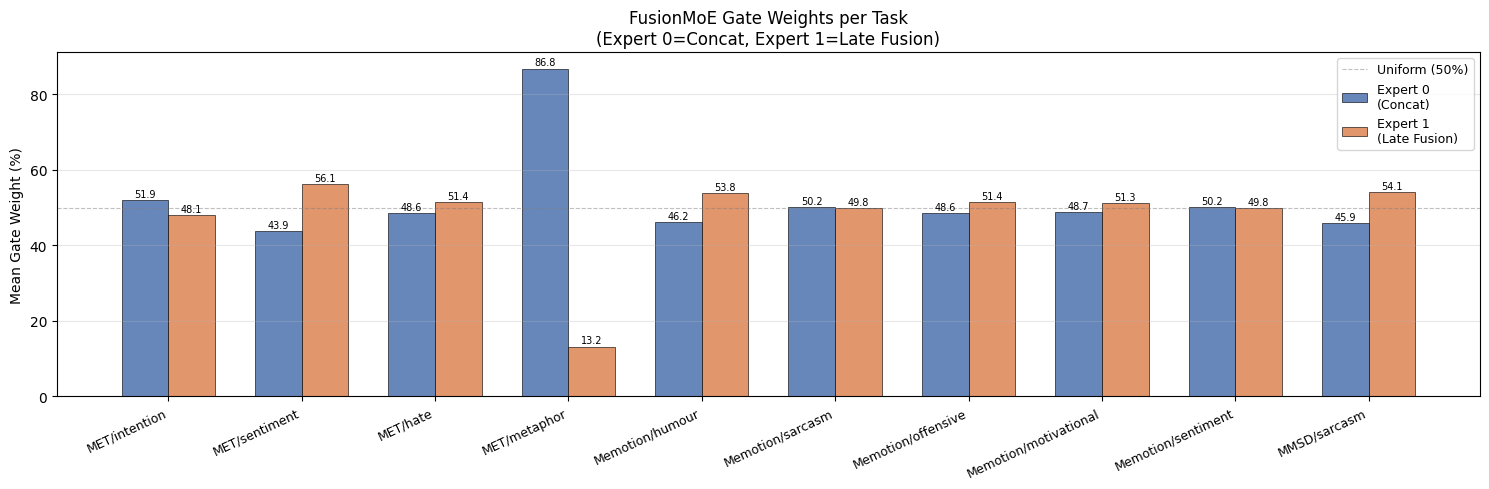


Task                         E0-Concat  E1-LateFusion
───────────────────────────────────────────────────────
MET/intention                   0.519          0.481  ← Concat
MET/sentiment                   0.439          0.561  ← LateFusion
MET/hate                        0.486          0.514  ← LateFusion
MET/metaphor                    0.868          0.132  ← Concat
Memotion/humour                 0.462          0.538  ← LateFusion
Memotion/sarcasm                0.502          0.498  ← Concat
Memotion/offensive              0.486          0.514  ← LateFusion
Memotion/motivational           0.487          0.513  ← LateFusion
Memotion/sentiment              0.502          0.498  ← Concat
MMSD/sarcasm                    0.459          0.541  ← LateFusion


In [46]:
# ── Plot gate weights across all tasks ───────────────────────────────────────
all_gate_weights = {
    **met_gate_weights,
    **mem_gate_weights,
    'MMSD/sarcasm': mmsd_gate_weights,
}

plot_gate_weights(all_gate_weights,
                  title='FusionMoE Gate Weights per Task\n(Expert 0=Concat, Expert 1=Late Fusion)')

# ── Numeric summary ───────────────────────────────────────────────────────────
print(f'\n{"Task":<25} {"E0-Concat":>12} {"E1-LateFusion":>14}')
print('─' * 55)
for tname, gw in all_gate_weights.items():
    dominant = 'Concat' if gw[0] > gw[1] else 'LateFusion'
    print(f'{tname:<25} {gw[0]:>11.3f}  {gw[1]:>13.3f}  ← {dominant}')


## 11. MULT Token-Level — Patch & Text Token Sequences

Uses CLIP's **last transformer layer token outputs** instead of global [CLS] vectors:
- Image: 197 tokens × 768-d (ViT-B/32 internal dim, before projection)
- Text:   77 tokens × 512-d (CLIP text transformer hidden dim)

This gives MULT genuine sequence cross-attention rather than the degenerate seq_len=1 case.

**Pipeline:**
1. `cache_clip_tokens()` — re-encode with hooks to extract intermediate features; save as float16 `.npz`
2. `MULTTokenFusion` — accepts `(B, 197, 768)` and `(B, 77, 512)`; uses per-modality Conv1d to project to shared `embed_dim` before cross-attention
3. Separate token loaders per dataset (global-vector loaders kept for all other models)


In [41]:
# ── Step 1: Cache CLIP token-level features ───────────────────────────────────
# Image: hook on clip_model.visual.transformer.resblocks[-1] output → (197, B, 768)
# Text:  hook on clip_model.transformer.resblocks[-1] output         → (77,  B, 512)
# Saved as float16 to keep file size manageable (~1 GB per split for MMSD).
#
# Run this cell once per dataset; skip if .npz already exists.

def cache_clip_tokens(hf_split, label_fn, cache_path, text_key='caption', batch_size=32):
    """
    Extract last-layer token sequences from frozen CLIP ViT-B/32.
    Returns:
        img_tokens: (N, 197, 768)  float16
        txt_tokens: (N,  77, 512)  float16
        labels:     (N,)           int64
    Saves to cache_path as compressed npz (float16).
    """
    if os.path.exists(cache_path):
        print(f'  Loading {cache_path}')
        d = np.load(cache_path)
        return (torch.from_numpy(d['img'].astype(np.float32)),
                torch.from_numpy(d['txt'].astype(np.float32)),
                torch.from_numpy(d['lbl']))

    img_feats, txt_feats, all_lbl = [], [], []

    # ── Register forward hooks ────────────────────────────────────────────────
    _img_buf, _txt_buf = [], []

    def _img_hook(module, inp, out):
        # out: (seq, B, dim) — permute to (B, seq, dim)
        _img_buf.append(out.permute(1, 0, 2).detach().cpu().to(torch.float16))

    def _txt_hook(module, inp, out):
        _txt_buf.append(out.permute(1, 0, 2).detach().cpu().to(torch.float16))

    h_img = clip_model.visual.transformer.resblocks[-1].register_forward_hook(_img_hook)
    h_txt = clip_model.transformer.resblocks[-1].register_forward_hook(_txt_hook)

    class _DS(Dataset):
        def __init__(self, split):
            self.data = split
        def __len__(self):
            return len(self.data)
        def __getitem__(self, idx):
            row = self.data[idx]
            img = clip_preprocess(row['image'].convert('RGB'))
            txt = clip.tokenize([row[text_key]], truncate=True).squeeze(0)
            return img, txt, label_fn(row)

    loader = DataLoader(_DS(hf_split), batch_size=batch_size, shuffle=False)

    clip_model.eval()
    with torch.no_grad():
        for imgs, texts, labels in tqdm(loader, desc='Encoding tokens', leave=False):
            imgs, texts = imgs.to(device), texts.to(device)
            _img_buf.clear(); _txt_buf.clear()
            clip_model.encode_image(imgs)
            clip_model.encode_text(texts)
            img_feats.append(_img_buf[0].cpu())   # (B, 197, 768)
            txt_feats.append(_txt_buf[0].cpu())   # (B,  77, 512)
            all_lbl.append(labels)

    h_img.remove(); h_txt.remove()

    img_t = torch.cat(img_feats)   # (N, 197, 768)
    txt_t = torch.cat(txt_feats)   # (N,  77, 512)
    lbl_t = torch.cat(all_lbl)

    np.savez_compressed(cache_path,
                        img=img_t.numpy().astype(np.float16),
                        txt=txt_t.numpy().astype(np.float16),
                        lbl=lbl_t.numpy())
    size_mb = os.path.getsize(cache_path) / 1e6
    print(f'  Saved → {cache_path}  ({size_mb:.0f} MB,  img:{img_t.shape}  txt:{txt_t.shape})')
    return img_t.float(), txt_t.float(), lbl_t


def make_token_loaders(img_tok, txt_tok, lbl, batch_size=32):
    ds = TensorDataset(img_tok, txt_tok, lbl)
    return (DataLoader(ds, batch_size=batch_size, shuffle=True),
            DataLoader(ds, batch_size=batch_size, shuffle=False))


print('cache_clip_tokens() defined.')
print('  img: last ViT resblock → (N, 197, 768)')
print('  txt: last text resblock → (N, 77, 512)')


cache_clip_tokens() defined.
  img: last ViT resblock → (N, 197, 768)
  txt: last text resblock → (N, 77, 512)


In [42]:
# ── Step 2: MULTTokenFusion — token-sequence cross-modal transformer ──────────
# Inputs: img_tokens (B, 197, 768), txt_tokens (B, 77, 512)
# Per-modality Conv1d projects to shared embed_dim before cross-attention.
# Architecture identical to MULTFusion but seq_len > 1 → genuine cross-attention.

class MULTTokenFusion(nn.Module):
    """
    MULT with full token sequences from CLIP last layer.
      img_tokens: (B, 197, 768) — ViT-B/32 patch tokens
      txt_tokens: (B,  77, 512) — CLIP text tokens

    Per-modality Conv1d(in_dim → embed_dim) aligns dimensions before cross-attention.
    combined_dim = embed_dim * 4
    """
    def __init__(self, num_classes, embed_dim=64, num_heads=8, layers=3,
                 img_dim=768, txt_dim=512,
                 attn_drop=0.1, relu_drop=0.1, res_drop=0.1, embed_drop=0.1,
                 out_drop=0.1, attn_mask=False):
        super().__init__()
        n_mod        = 2
        in_dims      = [img_dim, txt_dim]
        combined_dim = embed_dim * n_mod * n_mod   # 256

        # Per-modality projection: different input dims → shared embed_dim
        self.proj = nn.ModuleList([
            nn.Conv1d(in_dims[i], embed_dim, kernel_size=1, bias=False)
            for i in range(n_mod)
        ])

        def _cross(nl): return _TransformerEncoder(
            embed_dim, num_heads, nl, attn_drop, relu_drop, res_drop, embed_drop, attn_mask)
        def _self(nl):  return _TransformerEncoder(
            embed_dim * n_mod, num_heads, nl, attn_drop, relu_drop, res_drop, embed_drop, attn_mask)

        self.trans     = nn.ModuleList([nn.ModuleList([_cross(layers) for _ in range(n_mod)])
                                        for _ in range(n_mod)])
        self.trans_mem = nn.ModuleList([_self(layers) for _ in range(n_mod)])

        self.proj1    = nn.Linear(combined_dim, combined_dim)
        self.proj2    = nn.Linear(combined_dim, combined_dim)
        self.out_drop = out_drop
        self.head     = nn.Linear(combined_dim, num_classes)
        for m in [self.proj1, self.proj2, self.head]:
            nn.init.xavier_uniform_(m.weight); nn.init.constant_(m.bias, 0.)

    def forward(self, img_tok, txt_tok):
        # img_tok: (B, 197, 768), txt_tok: (B, 77, 512)
        # → Conv1d needs (B, dim, seq) → permute
        feats = [img_tok, txt_tok]
        # (B, seq, dim) → (B, dim, seq) → Conv1d → (B, embed_dim, seq) → (seq, B, embed_dim)
        px = [self.proj[i](feats[i].permute(0, 2, 1)).permute(2, 0, 1)
              for i in range(2)]
        # px[0]: (197, B, embed_dim),  px[1]: (77, B, embed_dim)

        last_hs = []
        for i in range(2):
            h_parts = [self.trans[i][j](px[i], px[j], px[j]) for j in range(2)]
            h = torch.cat(h_parts, dim=2)    # (seq_i, B, embed_dim*2)
            h = self.trans_mem[i](h)         # (seq_i, B, embed_dim*2)
            last_hs.append(h[-1])            # (B, embed_dim*2) — CLS-like: last token

        out = torch.cat(last_hs, dim=1)      # (B, 256)
        out = out + self.proj2(F.dropout(F.relu(self.proj1(out)),
                                         p=self.out_drop, training=self.training))
        return self.head(out)


def compute_metrics_token(model_fn, loader):
    """Same as compute_metrics but loader yields (img_tok, txt_tok, lbl)."""
    preds, trues = [], []
    with torch.no_grad():
        for img_tok, txt_tok, lbl in loader:
            img_tok, txt_tok = img_tok.to(device), txt_tok.to(device)
            out = model_fn(img_tok, txt_tok)
            preds.extend(out.argmax(1).cpu().tolist())
            trues.extend(lbl.tolist())
    return (accuracy_score(trues, preds),
            f1_score(trues, preds, average='macro', zero_division=0),
            preds, trues)


def train_mult_token(model, tr_loader, va_loader, ckpt_path,
                     epochs=15, lr=1e-4, wd=1e-3, num_classes=None):
    """Train MULTTokenFusion on token-sequence loaders."""
    if os.path.exists(ckpt_path):
        print(f'  Loading {ckpt_path}')
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        return model

    model = model.to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    all_lbl = torch.cat([lbl for _, _, lbl in tr_loader]).long()
    _nc = (int(all_lbl.max().item()) + 1) if num_classes is None else num_classes
    counts  = torch.bincount(all_lbl, minlength=_nc).float()
    weights = (1.0 / counts.clamp(min=1)).to(device)
    weights = weights / weights.sum() * _nc
    criterion = nn.CrossEntropyLoss(weight=weights)

    best_f1, best_state = 0.0, None
    for epoch in range(epochs):
        model.train()
        for img_tok, txt_tok, lbl in tr_loader:
            img_tok, txt_tok, lbl = img_tok.to(device), txt_tok.to(device), lbl.long().to(device)
            opt.zero_grad()
            criterion(model(img_tok, txt_tok), lbl).backward()
            opt.step()

        model.eval()
        _, f1, _, _ = compute_metrics_token(model, va_loader)
        if f1 > best_f1:
            best_f1   = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'    ep {epoch+1:02d}  val_f1={f1:.4f}')

    model.load_state_dict(best_state)
    torch.save(best_state, ckpt_path)
    print(f'  Saved → {ckpt_path}  (best val_f1={best_f1:.4f})')
    return model


print('MULTTokenFusion + train_mult_token defined.')
print('  img_tokens (B,197,768) + txt_tokens (B,77,512) → cross-attention → classifier')


MULTTokenFusion + train_mult_token defined.
  img_tokens (B,197,768) + txt_tokens (B,77,512) → cross-attention → classifier


In [43]:
# ── Step 3: Run MULTTokenFusion on all datasets ───────────────────────────────
# Uncomment and run when ready. Token cache takes ~5-10 min per dataset on CPU.
# Each split saves as float16 npz; total disk ~2-4 GB across all three datasets.

# ── MET-Meme ──────────────────────────────────────────────────────────────────
# met_tok_emb = {}
# for split_name, split_data in [('train', hf['train']), ('val', hf['validation']), ('test', hf['test'])]:
#     img_t, txt_t, _ = cache_clip_tokens(
#         split_data, lambda r: 0,
#         cache_path=f'artifacts/moe/met_meme_tok_{split_name}.npz'
#     )
#     met_tok_emb[split_name] = (img_t, txt_t)
#
# mult_tok_met_results = {}
# for task in MET_TASKS:
#     tname, nc, lnames = task['name'], task['num_classes'], task['label_names']
#     loaders_tok = {}
#     for sname in ['train','val','test']:
#         lbl = torch.tensor([task['label_fn'](r) for r in hf[{'train':'train','val':'validation','test':'test'}[sname]]])
#         img_t, txt_t = met_tok_emb[sname]
#         tr_l, va_l = make_token_loaders(img_t, txt_t, lbl) if sname == 'train' else (None, None)
#         loaders_tok[sname] = DataLoader(TensorDataset(img_t, txt_t, lbl), batch_size=16, shuffle=(sname=='train'))
#     model_tok = train_mult_token(
#         MULTTokenFusion(nc), loaders_tok['train'], loaders_tok['val'],
#         f'artifacts/moe/met_{tname}_mult_tok.pt', num_classes=nc
#     )
#     _, f1, preds, trues = compute_metrics_token(model_tok, loaders_tok['test'])
#     mult_tok_met_results[tname] = {'f1': f1, 'preds': preds, 'trues': trues}
#     print(f'  MET-Meme/{tname}  F1={f1*100:.2f}%')

# ── Memotion ──────────────────────────────────────────────────────────────────
# (same pattern — cache per split, then loop over MEM_TASKS)

# ── MMSD 2.0 ──────────────────────────────────────────────────────────────────
# (same pattern — cache_clip_tokens with text_key='text')

print('Token-level MULT training block ready (commented out).')
print('Uncomment and run when token cache is available.')


Token-level MULT training block ready (commented out).
Uncomment and run when token cache is available.


## 12. LLM-style MoE — Linear Router on Hidden State

Standard LLM MoE design applied to multimodal fusion:

| Component | Design |
|-----------|--------|
| **Hidden state** | `h = cat(img_f, txt_f)` — 1024-d concatenation |
| **Router** | `nn.Linear(1024, E)` → softmax → weights `(w_1, …, w_E)` |
| **Experts** | 4 full-data trained baselines: Concat / Late Fusion / Incongruity Fusion / MULT |
| **Routing** | **Soft** — all experts run, logits weighted-summed |
| **Load balancing** | `L_aux = E · Σ f_i · p_i` (Switch Transformer formulation) |
| **Total loss** | `L = L_cls + α · L_aux` (α = 0.01) |

Unlike the cosine-incongruity router (MMOE), this router is **fully learned** from data
and can discover task-specific routing patterns beyond the incongruity signal.

In [49]:
# ── LLM-style MoE (Section 12) ──────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F

class LLMStyleRouter(nn.Module):
    """Linear router on cat(img_f, txt_f) — same design as standard LLM MoE."""
    def __init__(self, d_model: int = 1024, num_experts: int = 4):
        super().__init__()
        self.gate = nn.Linear(d_model, num_experts, bias=False)

    def forward(self, img_f, txt_f):
        h = torch.cat([img_f, txt_f], dim=-1)   # (B, 1024)
        logits = self.gate(h)                    # (B, E)
        probs  = F.softmax(logits, dim=-1)       # (B, E)
        return probs


class LLMMoEClassifier(nn.Module):
    """
    Soft-routing MoE with load-balancing loss.

    experts : list of nn.Module, each maps (img_f, txt_f) -> logits (B, C)
    alpha   : load-balancing loss weight (default 0.01)
    """
    def __init__(self, experts, d_model: int = 1024, alpha: float = 0.01):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.router  = LLMStyleRouter(d_model, len(experts))
        self.alpha   = alpha
        self.E       = len(experts)

    def forward(self, img_f, txt_f):
        probs = self.router(img_f, txt_f)            # (B, E)

        # Run all experts
        expert_logits = torch.stack(
            [ex(img_f, txt_f) for ex in self.experts], dim=1
        )                                             # (B, E, C)

        # Weighted sum over experts
        w = probs.unsqueeze(-1)                      # (B, E, 1)
        out = (w * expert_logits).sum(dim=1)         # (B, C)

        # Switch Transformer load-balancing loss
        # f_i  = fraction of tokens dispatched to expert i
        # p_i  = mean router probability for expert i
        f = probs.mean(dim=0)                        # (E,)
        p = probs.mean(dim=0)                        # same here (soft routing)
        load_balance_loss = self.E * (f * p).sum()

        return out, probs, load_balance_loss


def build_llm_moe(expert_concat, expert_late, expert_incong, expert_mult,
                  d_model=1024, alpha=0.01):
    """Wrap four full-data trained experts in an LLM-style learned-router MoE."""
    moe = LLMMoEClassifier(
        experts=[expert_concat, expert_late, expert_incong, expert_mult],
        d_model=d_model,
        alpha=alpha,
    )
    return moe.to(device)


# ── Training function for LLM MoE ───────────────────────────────────────────────
def train_llm_moe(model, tr_loader, va_loader, num_classes,
                  epochs=30, lr=1e-3, patience=7, weight_decay=1e-4):
    """
    Fine-tunes only the router (gate weights); experts are frozen by default.
    Set expert parameters to requires_grad=True before calling to also fine-tune them.
    """
    # Freeze experts, train only router
    for ex in model.experts:
        for p in ex.parameters():
            p.requires_grad_(False)
    for p in model.router.parameters():
        p.requires_grad_(True)

    # Compute class weights
    all_labels = torch.cat([y for _, _, y in tr_loader])
    counts  = torch.bincount(all_labels, minlength=num_classes).float()
    weights = (1.0 / counts.clamp(min=1)).to(device)
    weights = weights / weights.sum() * num_classes

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(weight=weights)

    best_val_acc, best_state, wait = 0.0, None, 0

    for ep in range(1, epochs + 1):
        model.train()
        for img_f, txt_f, labels in tr_loader:
            img_f, txt_f, labels = img_f.to(device), txt_f.to(device), labels.to(device)
            optimizer.zero_grad()
            logits, _, lb_loss = model(img_f, txt_f)
            loss = criterion(logits, labels) + model.alpha * lb_loss
            loss.backward()
            optimizer.step()
        scheduler.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for img_f, txt_f, labels in va_loader:
                img_f, txt_f, labels = img_f.to(device), txt_f.to(device), labels.to(device)
                logits, _, _ = model(img_f, txt_f)
                correct += (logits.argmax(1) == labels).sum().item()
                total   += labels.size(0)
        val_acc = correct / total
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state:
        model.load_state_dict(best_state)
    return model, best_val_acc


In [53]:
# ── Section 12: Train LLM-style MoE on each dataset ────────────────────────────
# Experts are re-trained fresh inside each task loop (same pattern as Sections 6-8),
# then frozen; only the router is learned.
from sklearn.metrics import f1_score as _f1

llm_moe_results = {}   # {dataset/task: (acc, macro_f1)}


# ── helper: build + train one LLM-MoE for a single task ─────────────────────
def _run_llm_moe(loaders, nc, ckpt_prefix, task_label=""):
    # Train base experts (same as main loop)
    base_models = {
        'Concat':             ConcatClassifier(nc),
        'Late Fusion':        LateFusionClassifier(nc),
        'Incongruity Fusion': IncongruityFusion(nc),
        'MULT':               MULTFusion(nc),
    }
    for mname, mdl in base_models.items():
        ckpt = f"{ckpt_prefix}_{mname.lower().replace(' ','_')}.pt"
        base_models[mname] = train_model(
            mdl, loaders['train'], loaders['val'], ckpt,
            is_moe=False, num_classes=nc
        )

    moe = build_llm_moe(
        expert_concat  = base_models['Concat'],
        expert_late    = base_models['Late Fusion'],
        expert_incong  = base_models['Incongruity Fusion'],
        expert_mult    = base_models['MULT'],
        d_model=1024, alpha=0.01,
    )
    moe, _ = train_llm_moe(moe, loaders['train'], loaders['val'], nc)

    moe.eval()
    preds, gts = [], []
    with torch.no_grad():
        for img_f, txt_f, labels in loaders['test']:
            logits, _, _ = moe(img_f.to(device), txt_f.to(device))
            preds.extend(logits.argmax(1).cpu().tolist())
            gts.extend(labels.tolist())

    acc = sum(p == g for p, g in zip(preds, gts)) / len(gts)
    f1  = _f1(gts, preds, average="macro", zero_division=0)
    print(f"  {task_label}: acc={acc:.3f}  macro-F1={f1:.3f}")
    return acc, f1


# ── MET-Meme ─────────────────────────────────────────────────────────────────
print("=" * 60)
print("MET-Meme  — LLM-style MoE")
print("=" * 60)
for task in MET_TASKS:
    tname = task['name']
    nc    = task['num_classes']
    split_map = {'train': hf['train'], 'val': hf['validation'], 'test': hf['test']}
    loaders = {}
    for sname, sdata in split_map.items():
        lbl = torch.tensor([task['label_fn'](r) for r in sdata])
        img_t, txt_t = met_emb[sname]
        ds = TensorDataset(img_t, txt_t, lbl)
        loaders[sname] = DataLoader(ds, batch_size=64, shuffle=(sname == 'train'))

    acc, f1 = _run_llm_moe(loaders, nc, f'artifacts/moe/llmmoe_met_{tname}', tname)
    llm_moe_results[f"MET-Meme/{tname}"] = (acc, f1)


# ── Memotion 7k ───────────────────────────────────────────────────────────────
print("=" * 60)
print("Memotion 7k  — LLM-style MoE")
print("=" * 60)
for task in MEM_TASKS:
    tname = task['name']
    nc    = task['num_classes']
    loaders = {}
    for sname in ['train', 'val', 'test']:
        df_split = mem_splits[sname]._df
        lbl = torch.tensor([task['merge'](r[task['col']]) for _, r in df_split.iterrows()])
        img_t, txt_t = mem_emb[sname]
        ds = TensorDataset(img_t, txt_t, lbl)
        loaders[sname] = DataLoader(ds, batch_size=64, shuffle=(sname == 'train'))

    acc, f1 = _run_llm_moe(loaders, nc, f'artifacts/moe/llmmoe_mem_{tname}', tname)
    llm_moe_results[f"Memotion/{tname}"] = (acc, f1)


# ── MMSD 2.0 ─────────────────────────────────────────────────────────────────
print("=" * 60)
print("MMSD 2.0  — LLM-style MoE")
print("=" * 60)
nc = 2
loaders = {}
for sname in ['train', 'val', 'test']:
    img_t, txt_t = mmsd_emb[sname]
    ds = TensorDataset(img_t, txt_t, mmsd_lbl[sname])
    loaders[sname] = DataLoader(ds, batch_size=64, shuffle=(sname == 'train'))

acc, f1 = _run_llm_moe(loaders, nc, 'artifacts/moe/llmmoe_mmsd_sarcasm', 'sarcasm')
llm_moe_results["MMSD/sarcasm"] = (acc, f1)


# ── Summary ───────────────────────────────────────────────────────────────────
print("\nLLM-MoE results summary:")
for k, (a, f) in llm_moe_results.items():
    print(f"  {k:<30s}  acc={a:.3f}  macro-F1={f:.3f}")


MET-Meme  — LLM-style MoE
  Loading artifacts/moe/llmmoe_met_intention_concat.pt
  Loading artifacts/moe/llmmoe_met_intention_late_fusion.pt
  Loading artifacts/moe/llmmoe_met_intention_incongruity_fusion.pt
  Loading artifacts/moe/llmmoe_met_intention_mult.pt
  intention: acc=0.444  macro-F1=0.289
  Loading artifacts/moe/llmmoe_met_sentiment_concat.pt
  Loading artifacts/moe/llmmoe_met_sentiment_late_fusion.pt
  Loading artifacts/moe/llmmoe_met_sentiment_incongruity_fusion.pt
  Loading artifacts/moe/llmmoe_met_sentiment_mult.pt
  sentiment: acc=0.450  macro-F1=0.288
  Loading artifacts/moe/llmmoe_met_hate_concat.pt
  Loading artifacts/moe/llmmoe_met_hate_late_fusion.pt
  Loading artifacts/moe/llmmoe_met_hate_incongruity_fusion.pt
  Loading artifacts/moe/llmmoe_met_hate_mult.pt
  hate: acc=0.859  macro-F1=0.376
  Loading artifacts/moe/llmmoe_met_metaphor_concat.pt
  Loading artifacts/moe/llmmoe_met_metaphor_late_fusion.pt
  Loading artifacts/moe/llmmoe_met_metaphor_incongruity_fusion.p

In [ ]:
# ── Full results table (Accuracy + Macro-F1) ─────────────────────────────────
# Merge LLM-MoE results into the per-dataset result dicts so they appear in the table.
# llm_moe_results keys: "MET-Meme/<tname>", "Memotion/<tname>", "MMSD/sarcasm"
if 'llm_moe_results' in dir():
    for task in MET_TASKS:
        tname = task['name']
        key   = f'MET-Meme/{tname}'
        if key in llm_moe_results:
            acc, f1 = llm_moe_results[key]
            met_all_results[tname]['LLM-MoE'] = {'acc': acc, 'f1': f1, 'preds': [], 'trues': []}
    for task in MEM_TASKS:
        tname = task['name']
        key   = f'Memotion/{tname}'
        if key in llm_moe_results:
            acc, f1 = llm_moe_results[key]
            mem_all_results[tname]['LLM-MoE'] = {'acc': acc, 'f1': f1, 'preds': [], 'trues': []}
    if 'MMSD/sarcasm' in llm_moe_results:
        acc, f1 = llm_moe_results['MMSD/sarcasm']
        mmsd_results['LLM-MoE'] = {'acc': acc, 'f1': f1, 'preds': [], 'trues': []}

MODEL_NAMES   = ['Unimodal-Image', 'Unimodal-Text', 'Concat', 'Late Fusion',
                 'Incongruity Fusion', 'MULT', 'MMOE',
                #  'LLM-MoE',
                #  'FusionMoE',
                 ]
FUSION_MODELS = ['Concat', 'Late Fusion', 'Incongruity Fusion', 'MULT', 'MMOE',
                #  'LLM-MoE',
                #  'FusionMoE',
                 ]
UNIMODAL      = ['Unimodal-Image', 'Unimodal-Text']

all_tasks = (
    [('MET-Meme', t['name'], met_all_results[t['name']]) for t in MET_TASKS] +
    [('Memotion', t['name'], mem_all_results[t['name']]) for t in MEM_TASKS] +
    [('MMSD',     'sarcasm', mmsd_results)]
)

# ── Text table ────────────────────────────────────────────────────────────────
col_w = 22
header = f'{"Dataset":<12} {"Task":<14}' + ''.join(f'{m:>{col_w}}' for m in MODEL_NAMES)
print(header)
print('─' * len(header))
for dataset, task, res in all_tasks:
    row_acc = f'{dataset:<12} {task:<10} Acc'
    row_f1  = f'{"":12} {"":10}  F1'
    for m in MODEL_NAMES:
        if m not in res:
            row_acc += f'{"N/A":>{col_w}}'
            row_f1  += f'{"N/A":>{col_w}}'
        else:
            row_acc += f'{res[m]["acc"]*100:>{col_w-1}.1f}%'
            row_f1  += f'{res[m]["f1"]*100:>{col_w-1}.1f}%'
    print(row_acc)
    print(row_f1)
    print()

# ── Build matrices ────────────────────────────────────────────────────────────
import matplotlib.colors as mcolors

task_labels = [f'{d}/{t}' for d, t, _ in all_tasks]

def build_matrix(metric):
    rows = []
    for _, _, res in all_tasks:
        best_uni = max(res[m][metric] for m in UNIMODAL if m in res)
        row = []
        for m in MODEL_NAMES:
            if m not in res:
                row.append(np.nan)
            elif m in UNIMODAL:
                row.append(res[m][metric] * 100)
            else:
                row.append((res[m][metric] - best_uni) * 100)
        rows.append(row)
    return np.array(rows)

acc_matrix = build_matrix('acc')
f1_matrix  = build_matrix('f1')

# ── Draw heatmap ──────────────────────────────────────────────────────────────
def _draw_heatmap(ax, matrix, title, uni_cols, fusion_cols):
    n_rows, n_cols = matrix.shape
    uni_idx = [MODEL_NAMES.index(m) for m in uni_cols]
    fus_idx = [MODEL_NAMES.index(m) for m in fusion_cols]

    uni_data = np.full_like(matrix, np.nan)
    for j in uni_idx: uni_data[:, j] = matrix[:, j]
    ax.imshow(uni_data, cmap='Greys', vmin=30, vmax=100, aspect='auto', alpha=0.6)

    fus_data = np.full_like(matrix, np.nan)
    for j in fus_idx: fus_data[:, j] = matrix[:, j]
    im = ax.imshow(fus_data, cmap='RdYlGn', vmin=-15, vmax=15, aspect='auto')

    ax.axvline(x=len(uni_idx) - 0.5, color='black', linewidth=1.5)
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(MODEL_NAMES, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(task_labels)))
    ax.set_yticklabels(task_labels, fontsize=9)

    for i in range(n_rows):
        for j in range(n_cols):
            v = matrix[i, j]
            if np.isnan(v): continue
            if j in uni_idx:
                label, color = f'{v:.1f}%', 'black'
            else:
                sign  = '+' if v >= 0 else ''
                label = f'{sign}{v:.1f}%'
                color = 'black' if -12 < v < 12 else 'white'
            ax.text(j, i, label, ha='center', va='center', fontsize=8, color=color)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Δ vs best-Unimodal (%)')
    ax.text(-0.5, -0.7, '(grey cols = absolute score)', fontsize=7,
            color='grey', transform=ax.transData, ha='left', va='top')
    ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(40, 6))
_draw_heatmap(axes[0], acc_matrix,
              'Accuracy — Fusion Δ vs best Unimodal', UNIMODAL, FUSION_MODELS)
_draw_heatmap(axes[1], f1_matrix,
              'Macro-F1 — Fusion Δ vs best Unimodal', UNIMODAL, FUSION_MODELS)
plt.tight_layout()
plt.savefig('results/moe_full_heatmap.png', dpi=150)
plt.show()


KeyError: 'intention'

## 13. Comparison with LLM Baselines

Direct comparison of our best trained fusion models against LLM zero-shot baselines
(GPT-4o, Gemini-2.5-Flash, o4-mini, Gemini-2.5-Flash CoT, Qwen3-VL-30B thinking)
across all tasks and datasets.

All LLM numbers are evaluated on 50-sample subsets. Trained models use full test splits.

MACRO-F1 COMPARISON TABLE
Dataset    Task           Unimoda Unimoda  Concat Late Fu Incongr    MULT    MMOE LLM-MoE  GPT-4o Gemini- o4-mini Gemini- Qwen3-V
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
MET-Meme   intention        31.8%   29.7%   31.7%   30.7%   21.2%   27.0%   27.3%   28.9% |   35.3%   33.6%   44.7%   26.6%   40.0%
MET-Meme   sentiment        24.7%   23.7%   31.0%   27.8%   25.3%   24.3%   26.8%   28.8% |   28.3%   32.7%   33.3%   38.6%   30.2%
MET-Meme   hate             39.1%   38.8%   37.5%   38.0%   37.3%   41.4%   38.3%   37.6% |   29.8%   35.6%   44.4%   30.2%   31.4%
MET-Meme   metaphor         81.2%   75.5%   82.9%   81.8%   87.6%   84.7%   87.6%   87.6% |   36.7%   71.3%   73.1%   63.5%   57.1%
Memotion   humour           36.0%   33.2%   35.8%   36.2%   27.3%   36.2%   28.3%   30.1% |   27.0%   31.0%   30.3%   21.3%   32.0%
Memotion   sarcasm          33.3%   32.6%   30.2%   32

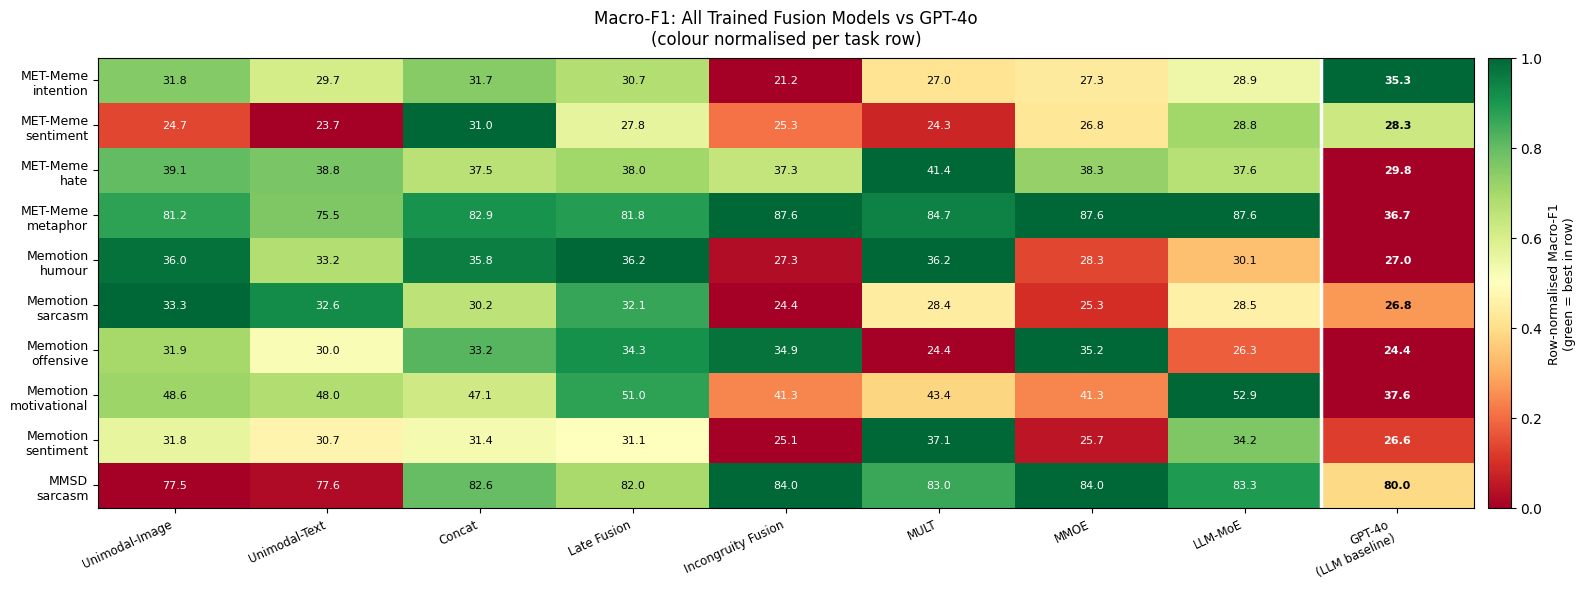

Saved: results/llm_vs_trained_heatmap.png

Dataset     Task            Best Trained F1  Best LLM F1        Δ
─────────────────────────────────────────────────────────────────
MET-Meme    intention                 31.8%         44.7%   -12.9%
MET-Meme    sentiment                 31.0%         38.6%    -7.6%
MET-Meme    hate                      41.4%         44.4%    -3.0%
MET-Meme    metaphor                  87.6%         73.1%  +  14.5%
Memotion    humour                    36.2%         32.0%  +   4.2%
Memotion    sarcasm                   33.3%         49.0%   -15.7%
Memotion    offensive                 35.2%         59.9%   -24.7%
Memotion    motivational              52.9%         38.7%  +  14.2%
Memotion    sentiment                 37.1%         26.6%  +  10.5%
MMSD        sarcasm                   84.0%         85.9%    -1.9%

ACCURACY COMPARISON TABLE
Dataset    Task           Unimoda Unimoda  Concat Late Fu Incongr    MULT    MMOE LLM-MoE  GPT-4o Gemini- o4-mini Gemini- Qw

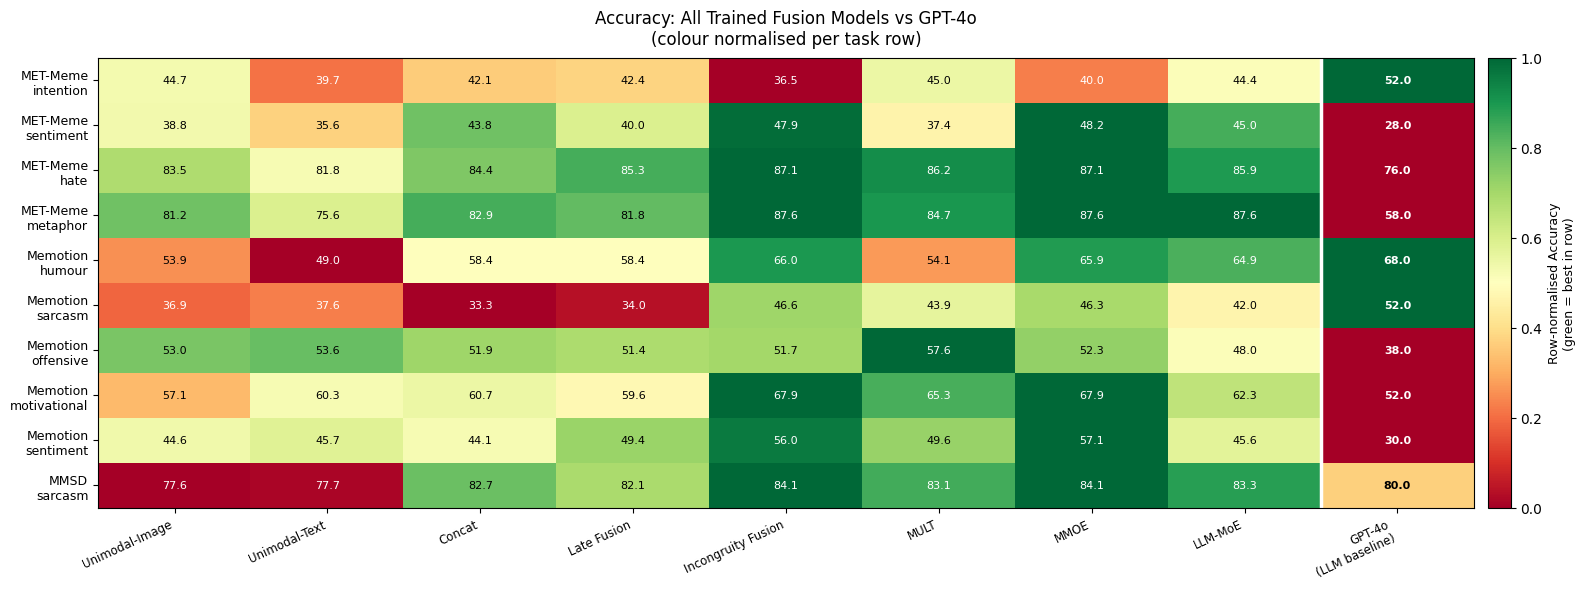

Saved: results/llm_vs_trained_acc_heatmap.png

Dataset     Task            Best Trained Acc  Best LLM Acc        Δ
─────────────────────────────────────────────────────────────────
MET-Meme    intention                  45.0%          56.0%   -11.0%
MET-Meme    sentiment                  48.2%          36.0%  +  12.2%
MET-Meme    hate                       87.1%          86.0%  +   1.1%
MET-Meme    metaphor                   87.6%          74.0%  +  13.6%
Memotion    humour                     66.0%          68.0%    -2.0%
Memotion    sarcasm                    46.6%          56.0%    -9.4%
Memotion    offensive                  57.6%          46.0%  +  11.6%
Memotion    motivational               67.9%          54.0%  +  13.9%
Memotion    sentiment                  57.1%          30.0%  +  27.1%
MMSD        sarcasm                    84.1%          86.0%    -1.9%


In [56]:

import numpy as np
import matplotlib.pyplot as plt

# ── LLM baseline results (50-sample eval) ─────────────────────────────────────
LLM_RESULTS = {
    ('MET-Meme', 'intention'): {
        'GPT-4o':               (0.52, 0.353),
        'Gemini-2.5-Flash':     (0.48, 0.336),
        'o4-mini':              (0.56, 0.447),
        'Gemini-2.5-Flash-CoT': (0.46, 0.266),
        'Qwen3-VL-30B':         (0.50, 0.400),
    },
    ('MET-Meme', 'sentiment'): {
        'GPT-4o':               (0.28, 0.283),
        'Gemini-2.5-Flash':     (0.34, 0.327),
        'o4-mini':              (0.32, 0.333),
        'Gemini-2.5-Flash-CoT': (0.36, 0.386),
        'Qwen3-VL-30B':         (0.32, 0.302),
    },
    ('MET-Meme', 'hate'): {
        'GPT-4o':               (0.76, 0.298),
        'Gemini-2.5-Flash':     (0.74, 0.356),
        'o4-mini':              (0.86, 0.444),
        'Gemini-2.5-Flash-CoT': (0.76, 0.302),
        'Qwen3-VL-30B':         (0.82, 0.314),
    },
    ('MET-Meme', 'metaphor'): {
        'GPT-4o':               (0.58, 0.367),
        'Gemini-2.5-Flash':     (0.72, 0.713),
        'o4-mini':              (0.74, 0.731),
        'Gemini-2.5-Flash-CoT': (0.64, 0.635),
        'Qwen3-VL-30B':         (0.64, 0.571),
    },
    ('Memotion', 'humour'): {
        'GPT-4o':               (0.68, 0.270),
        'Gemini-2.5-Flash':     (0.68, 0.310),
        'o4-mini':              (0.66, 0.303),
        'Gemini-2.5-Flash-CoT': (0.46, 0.213),
        'Qwen3-VL-30B':         (0.68, 0.320),
    },
    ('Memotion', 'sarcasm'): {
        'GPT-4o':               (0.52, 0.268),
        'Gemini-2.5-Flash':     (0.50, 0.388),
        'o4-mini':              (0.56, 0.440),
        'Gemini-2.5-Flash-CoT': (0.44, 0.386),
        'Qwen3-VL-30B':         (0.54, 0.490),
    },
    ('Memotion', 'offensive'): {
        'GPT-4o':               (0.38, 0.244),
        'Gemini-2.5-Flash':     (0.46, 0.312),
        'o4-mini':              (0.42, 0.599),
        'Gemini-2.5-Flash-CoT': (0.38, 0.293),
        'Qwen3-VL-30B':         (0.40, 0.269),
    },
    ('Memotion', 'motivational'): {
        'GPT-4o':               (0.52, 0.376),
        'Gemini-2.5-Flash':     (0.54, 0.387),
        'o4-mini':              (0.52, 0.376),
        'Gemini-2.5-Flash-CoT': (0.46, 0.372),
        'Qwen3-VL-30B':         (0.54, 0.387),
    },
    ('Memotion', 'sentiment'): {
        'GPT-4o':               (0.30, 0.266),
        'Gemini-2.5-Flash':     (0.26, 0.239),
        'o4-mini':              (0.28, 0.265),
        'Gemini-2.5-Flash-CoT': (0.22, 0.217),
        'Qwen3-VL-30B':         (0.24, 0.187),
    },
    ('MMSD', 'sarcasm'): {
        'GPT-4o':               (0.80, 0.800),
        'Gemini-2.5-Flash':     (0.86, 0.859),
        'o4-mini':              (0.84, 0.840),
        'Gemini-2.5-Flash-CoT': (0.74, 0.740),
        'Qwen3-VL-30B':         (0.58, 0.572),
    },
}

TASK_ORDER = [
    ('MET-Meme', 'intention'), ('MET-Meme', 'sentiment'),
    ('MET-Meme', 'hate'),      ('MET-Meme', 'metaphor'),
    ('Memotion', 'humour'),    ('Memotion', 'sarcasm'),
    ('Memotion', 'offensive'), ('Memotion', 'motivational'),
    ('Memotion', 'sentiment'), ('MMSD',     'sarcasm'),
]

TRAINED_MODELS = ['Unimodal-Image', 'Unimodal-Text', 'Concat', 'Late Fusion',
                  'Incongruity Fusion', 'MULT', 'MMOE', 'LLM-MoE']
LLM_MODELS     = ['GPT-4o', 'Gemini-2.5-Flash', 'o4-mini',
                  'Gemini-2.5-Flash-CoT', 'Qwen3-VL-30B']

# ── helpers ───────────────────────────────────────────────────────────────────
def _get_res(dataset, task):
    if dataset == 'MET-Meme': return met_all_results.get(task, {})
    if dataset == 'Memotion':  return mem_all_results.get(task, {})
    return mmsd_results

def _trained(dataset, task, model, metric):
    r = _get_res(dataset, task)
    if model not in r: return None
    return r[model][metric]

def _llm(dataset, task, model, metric):
    idx = 0 if metric == 'acc' else 1
    return LLM_RESULTS.get((dataset, task), {}).get(model, (None, None))[idx]

# ══════════════════════════════════════════════════════════════════════════════
# 1. Full combined text table (Macro-F1 only for readability)
# ══════════════════════════════════════════════════════════════════════════════
ALL_COLS = TRAINED_MODELS + LLM_MODELS
COL_W = 8

sep_after = len(TRAINED_MODELS) - 1   # draw separator between trained & LLM cols

header = f'{"Dataset":<10} {"Task":<14}' + ''.join(f'{c[:7]:>{COL_W}}' for c in ALL_COLS)
print('MACRO-F1 COMPARISON TABLE')
print('=' * len(header))
print(header)
print('─' * len(header))

for ds, task in TASK_ORDER:
    row = f'{ds:<10} {task:<14}'
    for ci, col in enumerate(ALL_COLS):
        if col in TRAINED_MODELS:
            v = _trained(ds, task, col, 'f1')
        else:
            v = _llm(ds, task, col, 'f1')
        cell = f'{v*100:.1f}%' if v is not None else 'N/A'
        row += f'{cell:>{COL_W}}'
        if ci == sep_after:
            row += ' |'   # visual separator
    print(row)

print('─' * len(header))
print(f'{"":10} {"":14}' +
      ''.join(f'{"[trained]":>{COL_W}}' if c in TRAINED_MODELS else f'{"[LLM]":>{COL_W}}'
              for c in ALL_COLS))
print()

# ══════════════════════════════════════════════════════════════════════════════
# 2. Heatmap — row-normalised, GPT-4o as LLM representative
#    Columns: trained models + GPT-4o
#    Color = row-min-max normalisation so each task's range fills [0,1]
# ══════════════════════════════════════════════════════════════════════════════
HMAP_COLS   = TRAINED_MODELS + ['GPT-4o']
TASK_LABELS = [f'{ds}\n{task}' for ds, task in TASK_ORDER]

# Build raw F1 matrix
raw = np.full((len(TASK_ORDER), len(HMAP_COLS)), np.nan)
for ri, (ds, task) in enumerate(TASK_ORDER):
    for ci, col in enumerate(HMAP_COLS):
        if col in TRAINED_MODELS:
            v = _trained(ds, task, col, 'f1')
        else:
            v = _llm(ds, task, col, 'f1')
        if v is not None:
            raw[ri, ci] = v * 100

# Row-normalise
normed = np.full_like(raw, np.nan)
for ri in range(len(TASK_ORDER)):
    row = raw[ri]
    valid = row[~np.isnan(row)]
    if len(valid) == 0: continue
    rmin, rmax = valid.min(), valid.max()
    denom = rmax - rmin if rmax > rmin else 1.0
    normed[ri] = (row - rmin) / denom

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(normed, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

# Annotate with raw F1 values
for ri in range(len(TASK_ORDER)):
    for ci in range(len(HMAP_COLS)):
        v = raw[ri, ci]
        n = normed[ri, ci]
        if np.isnan(v): continue
        txt_color = 'white' if n < 0.25 or n > 0.82 else 'black'
        weight = 'bold' if ci == len(HMAP_COLS) - 1 else 'normal'   # bold for GPT-4o
        ax.text(ci, ri, f'{v:.1f}', ha='center', va='center',
                fontsize=8, color=txt_color, fontweight=weight)

# Separator line before GPT-4o column
ax.axvline(len(TRAINED_MODELS) - 0.5, color='white', linewidth=2.5)

ax.set_xticks(range(len(HMAP_COLS)))
col_labels_disp = TRAINED_MODELS + ['GPT-4o\n(LLM baseline)']
ax.set_xticklabels(col_labels_disp, fontsize=8.5, rotation=25, ha='right')
ax.set_yticks(range(len(TASK_ORDER)))
ax.set_yticklabels(TASK_LABELS, fontsize=9)

cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label('Row-normalised Macro-F1\n(green = best in row)', fontsize=9)

ax.set_title('Macro-F1: All Trained Fusion Models vs GPT-4o\n'
             '(colour normalised per task row)', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('results/llm_vs_trained_heatmap.png', dpi=150)
plt.show()
print('Saved: results/llm_vs_trained_heatmap.png')

# ══════════════════════════════════════════════════════════════════════════════
# 3. Summary: best trained vs best LLM (all 5), per task
# ══════════════════════════════════════════════════════════════════════════════
print(f'\n{"Dataset":<11} {"Task":<14} {"Best Trained F1":>16} {"Best LLM F1":>12} {"Δ":>8}')
print('─' * 65)
for ds, task in TASK_ORDER:
    trained_vals = [_trained(ds, task, m, 'f1') for m in TRAINED_MODELS]
    trained_vals = [v for v in trained_vals if v is not None]
    llm_vals     = [_llm(ds, task, m, 'f1') for m in LLM_MODELS]
    llm_vals     = [v for v in llm_vals if v is not None]
    if not trained_vals or not llm_vals: continue
    bt  = max(trained_vals) * 100
    bl  = max(llm_vals)     * 100
    delta = bt - bl
    sign  = '+' if delta >= 0 else ''
    print(f'{ds:<11} {task:<14} {bt:>15.1f}%  {bl:>11.1f}%  {sign}{delta:>6.1f}%')


# ══════════════════════════════════════════════════════════════════════════════
# ACCURACY — same structure as Macro-F1 above, separate plots
# ══════════════════════════════════════════════════════════════════════════════

# 4. Full accuracy text table
print('\nACCURACY COMPARISON TABLE')
print('=' * len(header))
print(header)
print('─' * len(header))

for ds, task in TASK_ORDER:
    row = f'{ds:<10} {task:<14}'
    for ci, col in enumerate(ALL_COLS):
        if col in TRAINED_MODELS:
            v = _trained(ds, task, col, 'acc')
        else:
            v = _llm(ds, task, col, 'acc')
        cell = f'{v*100:.1f}%' if v is not None else 'N/A'
        row += f'{cell:>{COL_W}}'
        if ci == sep_after:
            row += ' |'
    print(row)

print('─' * len(header))
print(f'{"":10} {"":14}' +
      ''.join(f'{"[trained]":>{COL_W}}' if c in TRAINED_MODELS else f'{"[LLM]":>{COL_W}}'
              for c in ALL_COLS))
print()

# 5. Accuracy heatmap — row-normalised, GPT-4o as LLM representative
raw_acc = np.full((len(TASK_ORDER), len(HMAP_COLS)), np.nan)
for ri, (ds, task) in enumerate(TASK_ORDER):
    for ci, col in enumerate(HMAP_COLS):
        if col in TRAINED_MODELS:
            v = _trained(ds, task, col, 'acc')
        else:
            v = _llm(ds, task, col, 'acc')
        if v is not None:
            raw_acc[ri, ci] = v * 100

normed_acc = np.full_like(raw_acc, np.nan)
for ri in range(len(TASK_ORDER)):
    row = raw_acc[ri]
    valid = row[~np.isnan(row)]
    if len(valid) == 0: continue
    rmin, rmax = valid.min(), valid.max()
    denom = rmax - rmin if rmax > rmin else 1.0
    normed_acc[ri] = (row - rmin) / denom

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(normed_acc, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

for ri in range(len(TASK_ORDER)):
    for ci in range(len(HMAP_COLS)):
        v = raw_acc[ri, ci]
        n = normed_acc[ri, ci]
        if np.isnan(v): continue
        txt_color = 'white' if n < 0.25 or n > 0.82 else 'black'
        weight = 'bold' if ci == len(HMAP_COLS) - 1 else 'normal'
        ax.text(ci, ri, f'{v:.1f}', ha='center', va='center',
                fontsize=8, color=txt_color, fontweight=weight)

ax.axvline(len(TRAINED_MODELS) - 0.5, color='white', linewidth=2.5)
ax.set_xticks(range(len(HMAP_COLS)))
ax.set_xticklabels(col_labels_disp, fontsize=8.5, rotation=25, ha='right')
ax.set_yticks(range(len(TASK_ORDER)))
ax.set_yticklabels(TASK_LABELS, fontsize=9)

cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label('Row-normalised Accuracy\n(green = best in row)', fontsize=9)

ax.set_title('Accuracy: All Trained Fusion Models vs GPT-4o\n'
             '(colour normalised per task row)', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('results/llm_vs_trained_acc_heatmap.png', dpi=150)
plt.show()
print('Saved: results/llm_vs_trained_acc_heatmap.png')

# 6. Summary: best trained acc vs best LLM acc, per task
print(f'\n{"Dataset":<11} {"Task":<14} {"Best Trained Acc":>17} {"Best LLM Acc":>13} {"Δ":>8}')
print('─' * 65)
for ds, task in TASK_ORDER:
    trained_vals = [_trained(ds, task, m, 'acc') for m in TRAINED_MODELS]
    trained_vals = [v for v in trained_vals if v is not None]
    llm_vals     = [_llm(ds, task, m, 'acc') for m in LLM_MODELS]
    llm_vals     = [v for v in llm_vals if v is not None]
    if not trained_vals or not llm_vals: continue
    bt    = max(trained_vals) * 100
    bl    = max(llm_vals)     * 100
    delta = bt - bl
    sign  = '+' if delta >= 0 else ''
    print(f'{ds:<11} {task:<14} {bt:>16.1f}%  {bl:>12.1f}%  {sign}{delta:>6.1f}%')
